## Case 1 code Pure dephasing

QSER Analysis of Pure Dephasing: Numerical Values

Parameters:
  gamma = 0.5
  Initial state: rho_00(0) = 0.5, rho_11(0) = 0.5
  Initial coherence: rho_01(0) = 0.5

Reconstruction Error (QSER vs Literature):
  max |rho_00(QSER) - rho_00(Literature)| = 0.00e+00
  max |rho_11(QSER) - rho_11(Literature)| = 0.00e+00
  max |rho_01(QSER) - rho_01(Literature)| = 2.78e-17
  max |rho_10(QSER) - rho_10(Literature)| = 2.78e-17

Continuity Equation Error (Variant 3):
  max |J - dE/dt - D_E| = 2.78e-17
  mean |J - dE/dt - D_E| = 2.97e-18

Inheritance Measure:
  I(t_final) = 0.993262
  Final coherence of actual state = 0.003369
  Final coherence of ghost = 0.500000

Memory Kernel:
  Memory time scale tau = 1/(2*gamma) = 1.0000



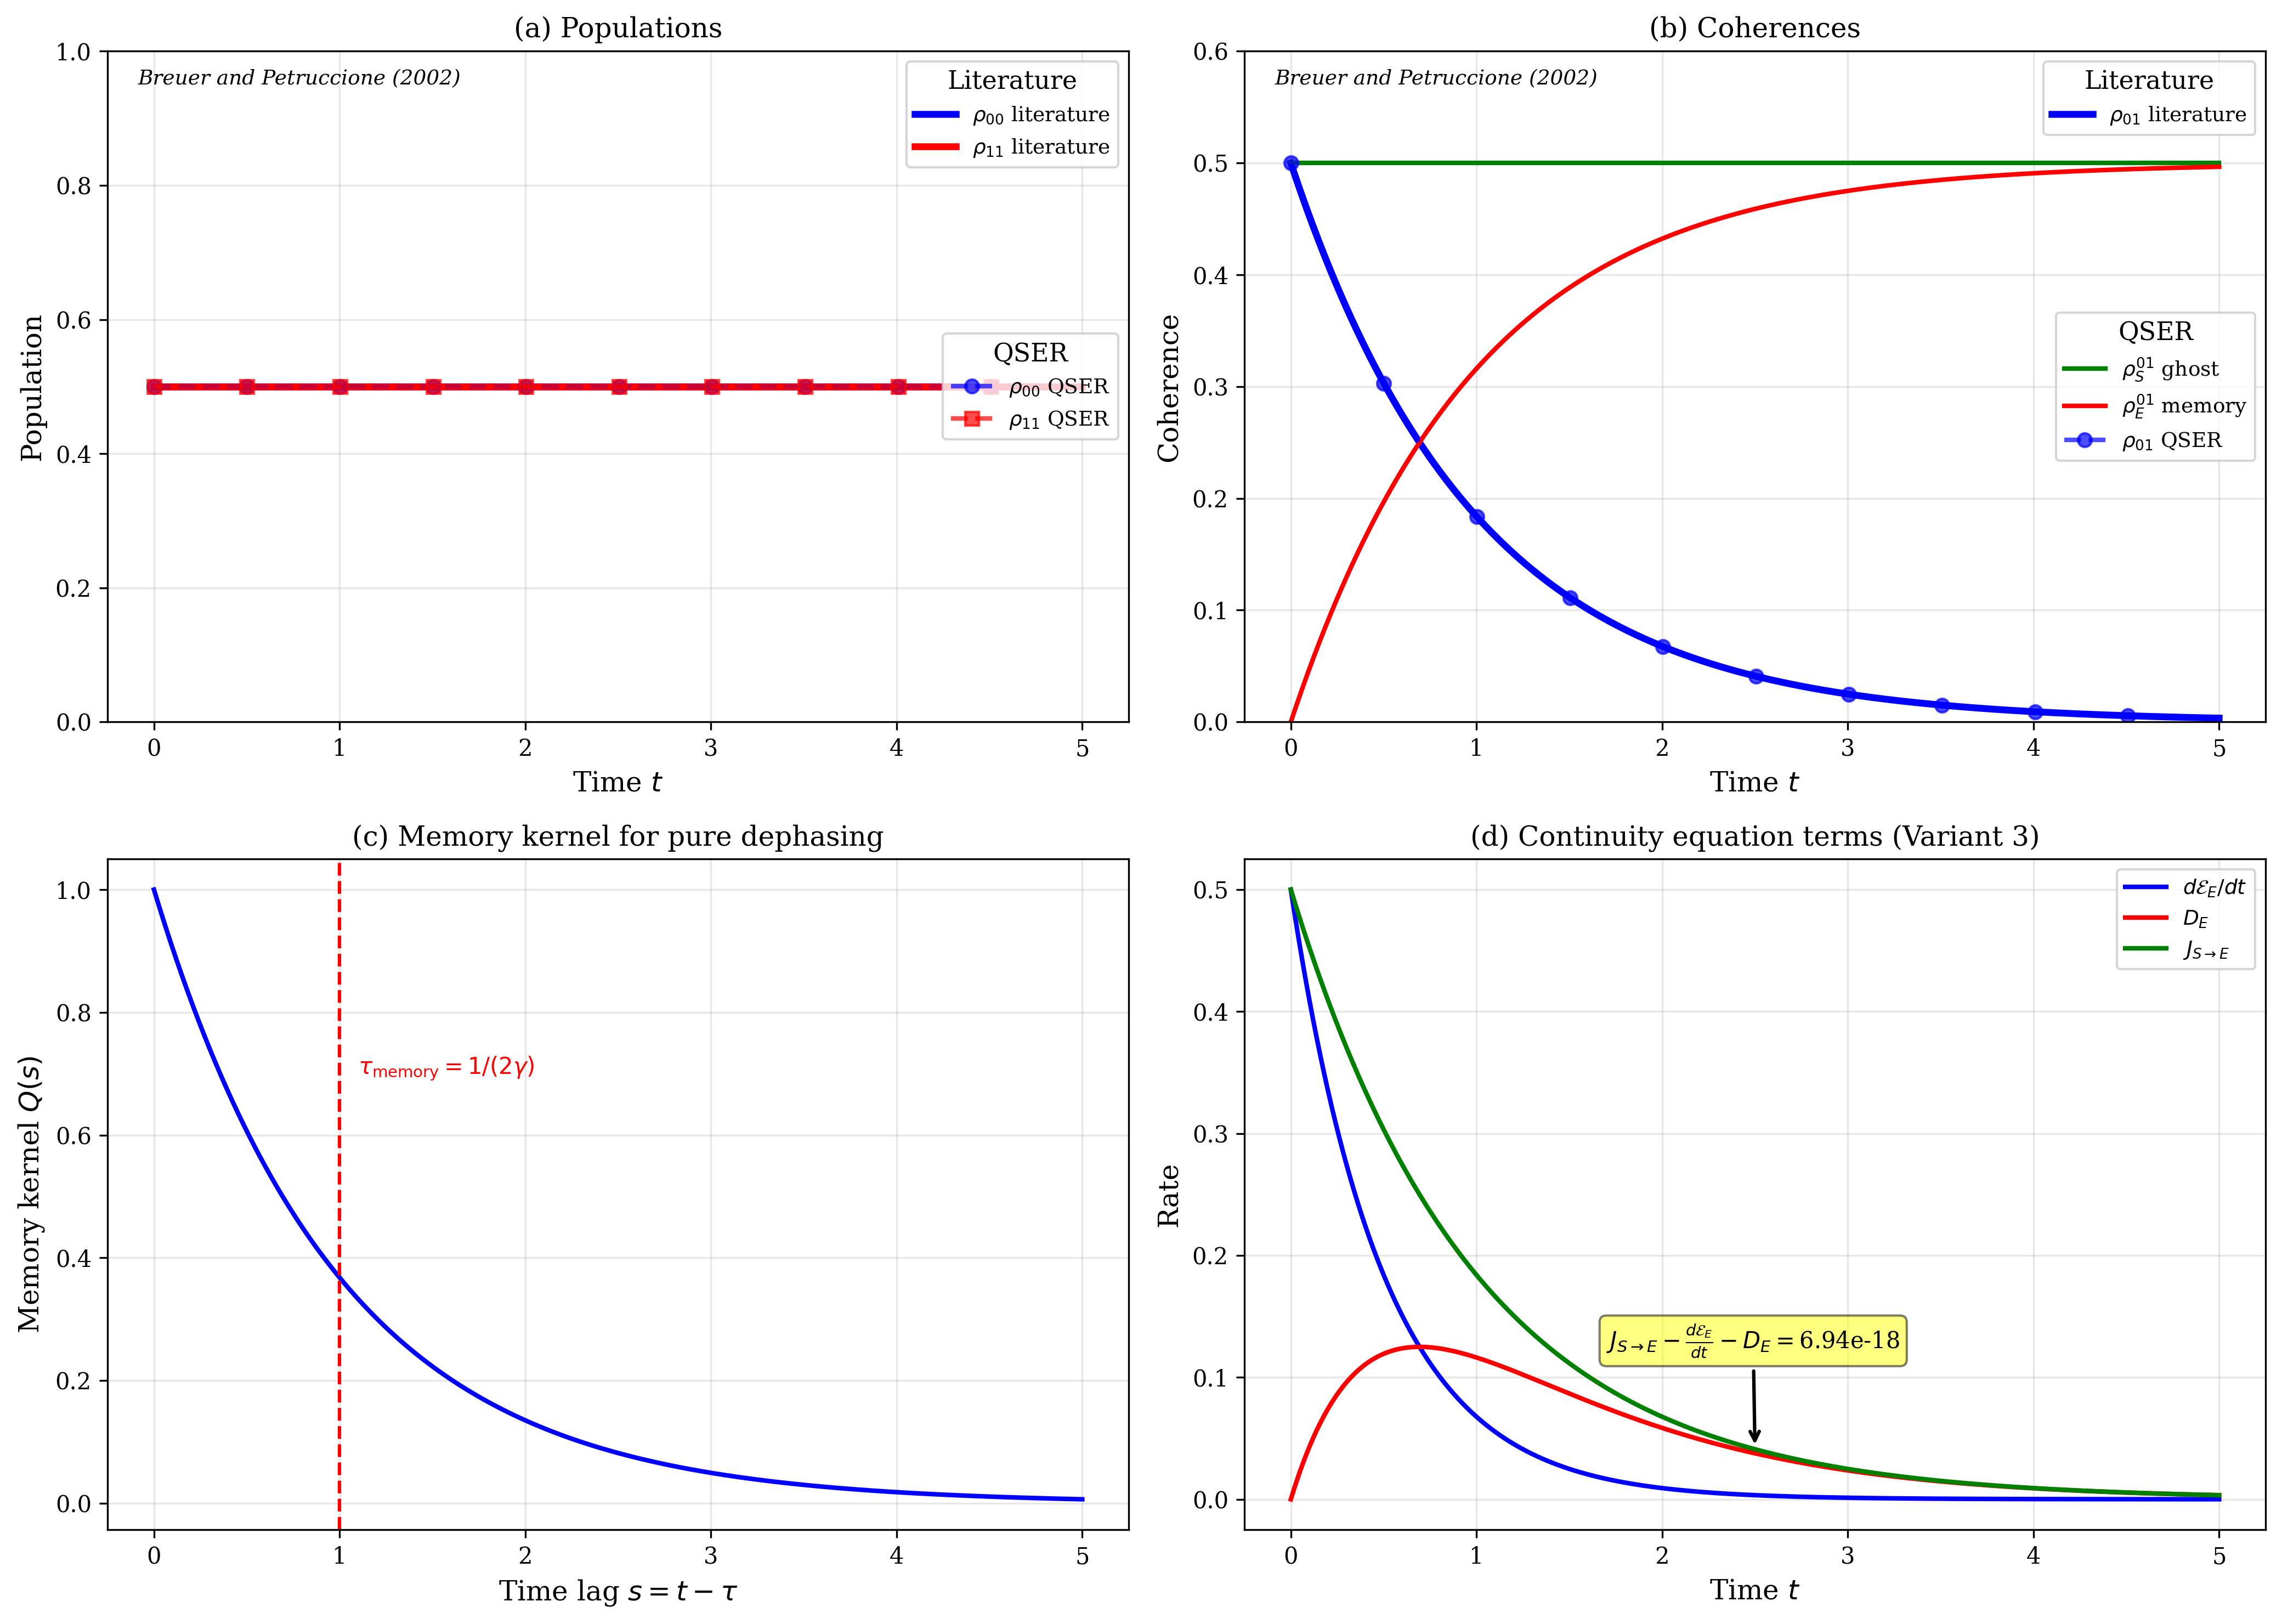

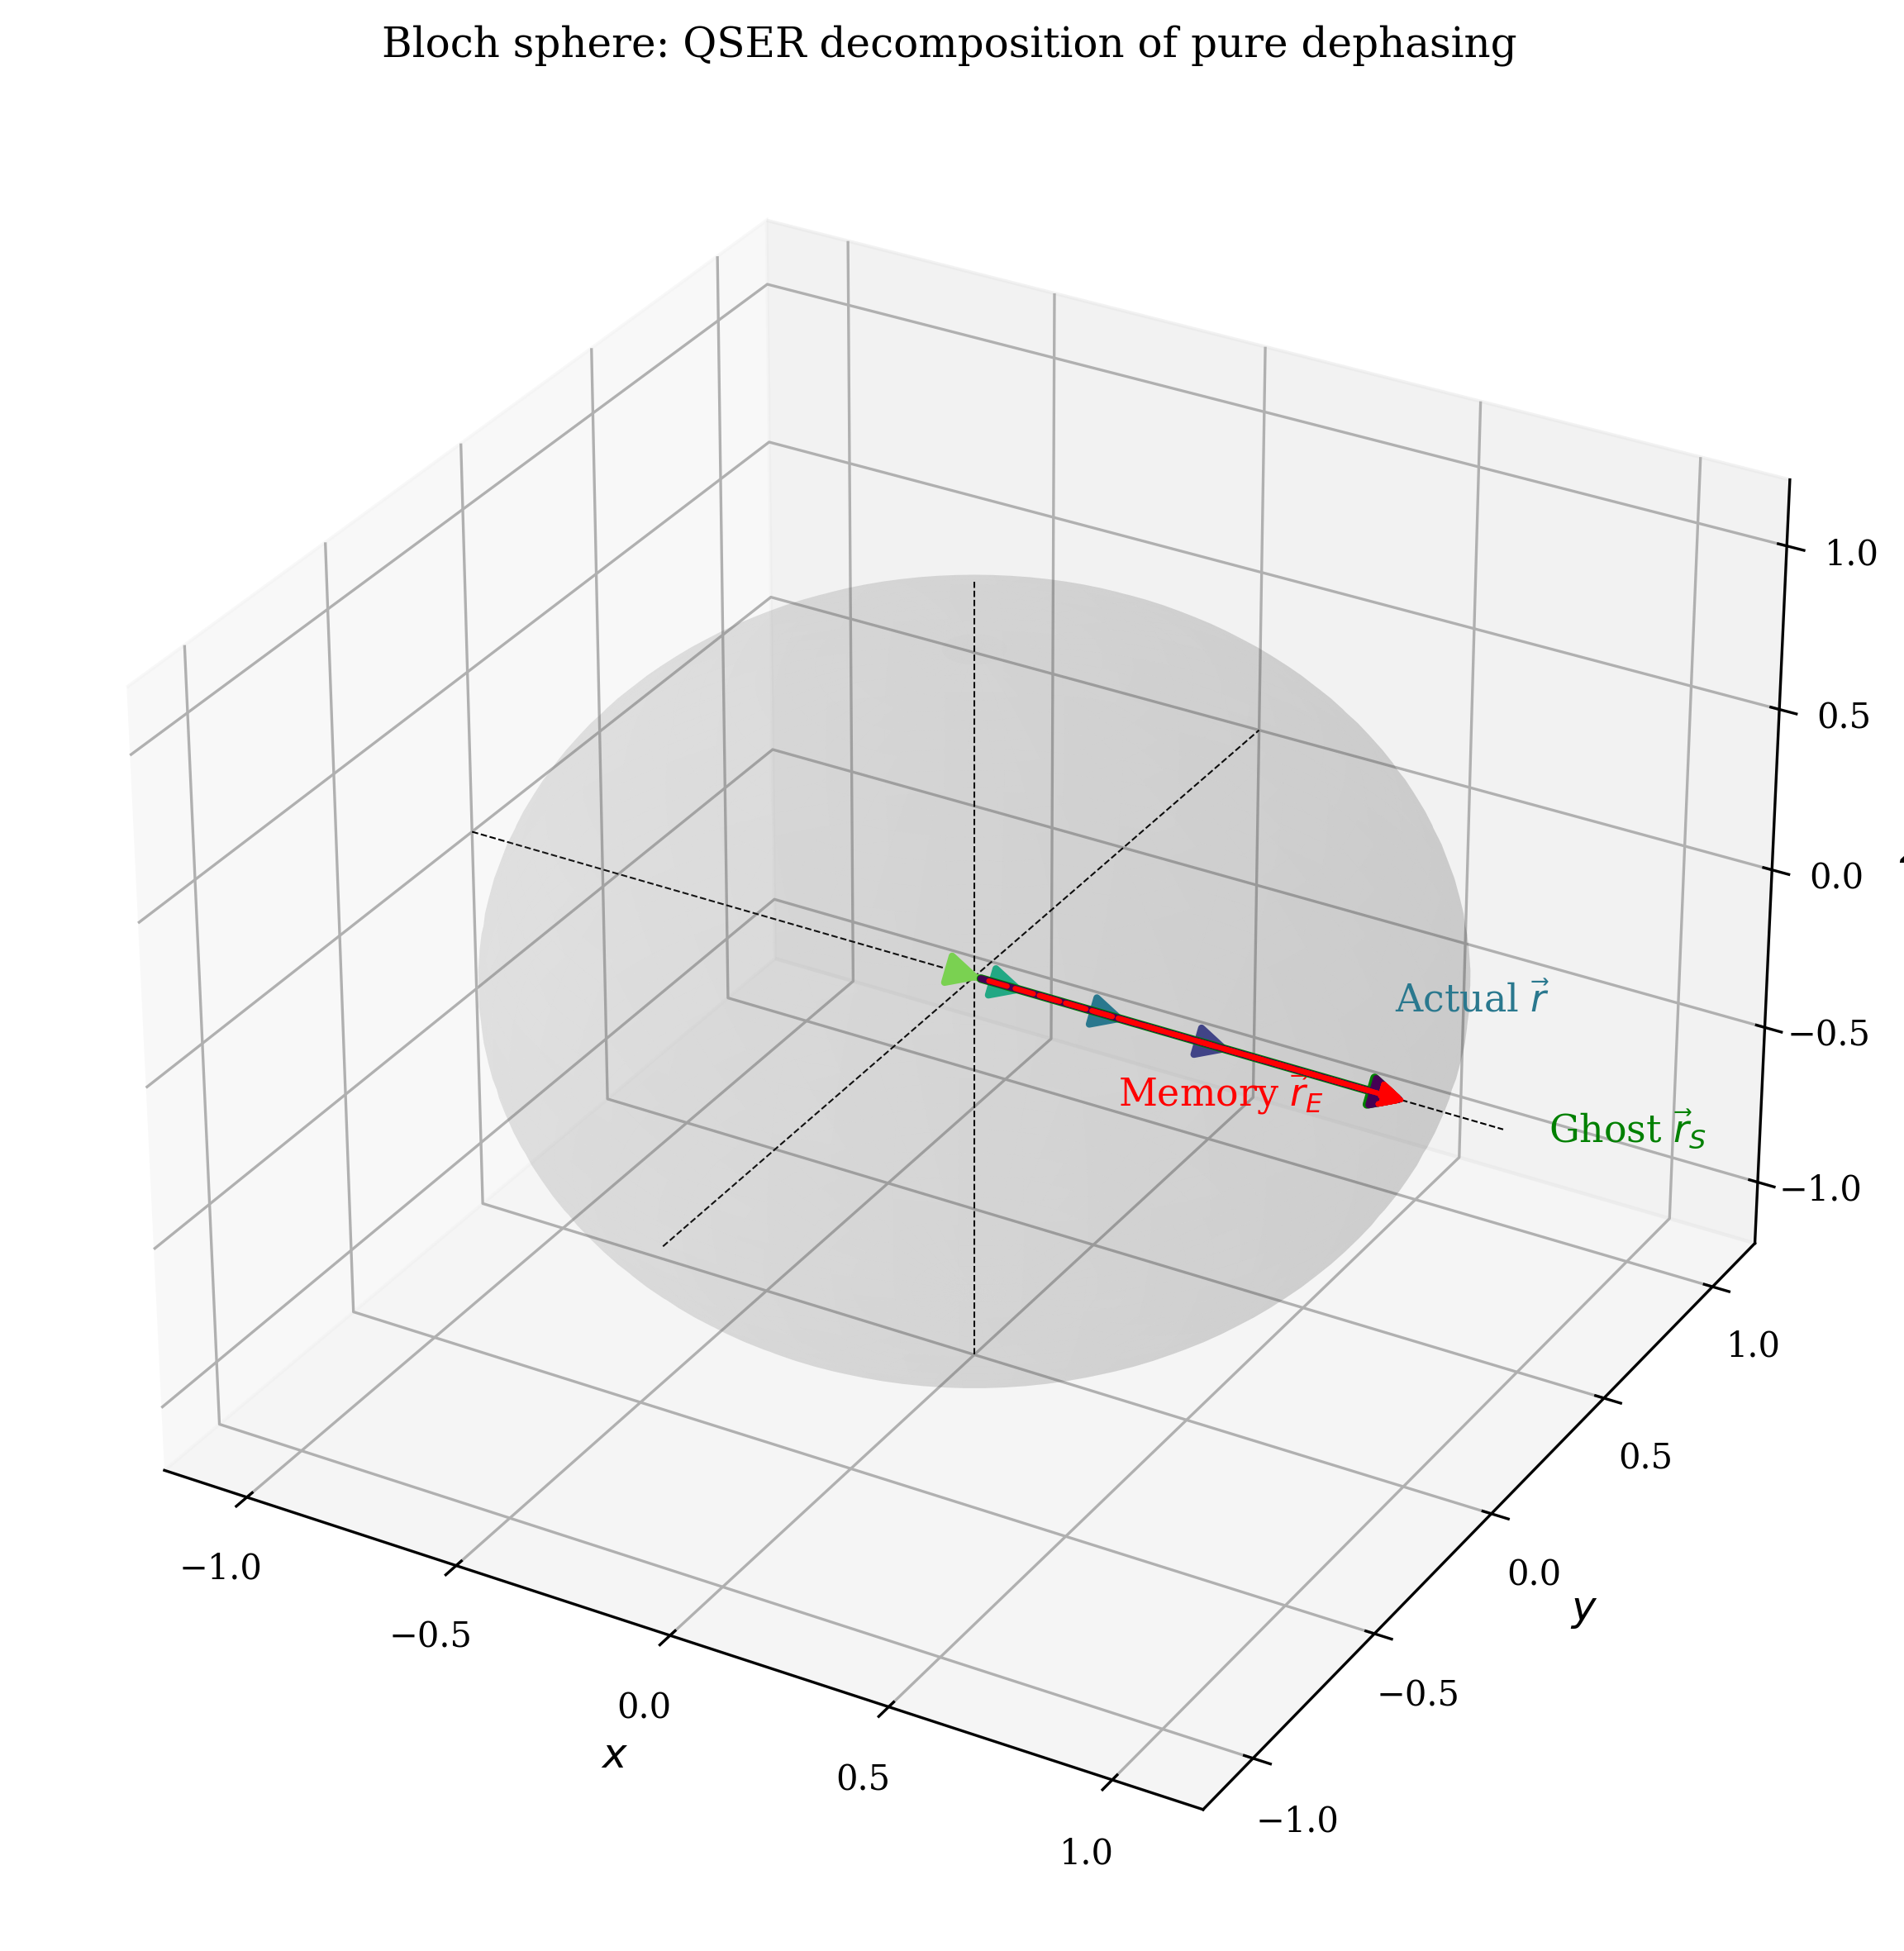

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import os

# Set save path
#save_path = 'write your path here'
#os.makedirs(save_path, exist_ok=True)

# Set style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.bbox': 'tight'
})

# Parameters
gamma = 0.5
t = np.linspace(0, 5, 500)
s = np.linspace(0, 5, 500)

# Initial state: pure superposition
rho_00_0 = 0.5
rho_11_0 = 0.5
rho_01_0 = 0.5
rho_10_0 = 0.5

# Literature solution (Breuer and Petruccione, 2002; Nielsen and Chuang, 2010)
rho_00_lit = rho_00_0 * np.ones_like(t)
rho_11_lit = rho_11_0 * np.ones_like(t)
rho_01_lit = rho_01_0 * np.exp(-2 * gamma * t)
rho_10_lit = rho_10_0 * np.exp(-2 * gamma * t)

# QSER ghost (frozen since L_c = d/dt, so d(rho_S)/dt = 0)
rho_S_00 = rho_00_0 * np.ones_like(t)
rho_S_11 = rho_11_0 * np.ones_like(t)
rho_S_01 = rho_01_0 * np.ones_like(t)
rho_S_10 = rho_10_0 * np.ones_like(t)

# QSER environmental memory
rho_E_00 = np.zeros_like(t)
rho_E_11 = np.zeros_like(t)
rho_E_01 = rho_01_0 * (1 - np.exp(-2 * gamma * t))
rho_E_10 = rho_10_0 * (1 - np.exp(-2 * gamma * t))

# QSER reconstruction
rho_00_qser = rho_S_00 - rho_E_00
rho_11_qser = rho_S_11 - rho_E_11
rho_01_qser = rho_S_01 - rho_E_01
rho_10_qser = rho_S_10 - rho_E_10

# Time derivative of environmental memory
rho_E_dot_01 = 2 * gamma * rho_01_0 * np.exp(-2 * gamma * t)
rho_E_dot_10 = 2 * gamma * rho_10_0 * np.exp(-2 * gamma * t)

# Continuity equation terms using Variant 3 (Pure Power Form)
# L_c[rho_E] = d(rho_E)/dt (since H = 0)
dE_E_dt = 2 * np.abs(rho_E_dot_01)**2

# Dissipation: D_E = Tr(rho_E_dot^dag L_d[rho_E])
# L_d[rho] = -gamma(sigma_z rho sigma_z - rho)
# L_d[rho_E]^01 = +2 gamma rho_E^01
L_d_rho_E_01 = 2 * gamma * rho_E_01
L_d_rho_E_10 = 2 * gamma * rho_E_10

D_E = rho_E_dot_01 * L_d_rho_E_10 + rho_E_dot_10 * L_d_rho_E_01

# Flux: J_{S to E} = Tr(rho_E_dot^dag L_d[rho_S])
# L_d[rho_S]^01 = +2 gamma rho_S^01
L_d_rho_S_01 = 2 * gamma * rho_S_01
L_d_rho_S_10 = 2 * gamma * rho_S_10

J_S_to_E = rho_E_dot_01 * L_d_rho_S_10 + rho_E_dot_10 * L_d_rho_S_01

# Memory kernel
Q_s = np.exp(-2 * gamma * s)

# Compute errors
error_rho_00 = np.max(np.abs(rho_00_qser - rho_00_lit))
error_rho_11 = np.max(np.abs(rho_11_qser - rho_11_lit))
error_rho_01 = np.max(np.abs(rho_01_qser - rho_01_lit))
error_rho_10 = np.max(np.abs(rho_10_qser - rho_10_lit))

continuity_residual = J_S_to_E - dE_E_dt - D_E
continuity_max_error = np.max(np.abs(continuity_residual))
continuity_mean_error = np.mean(np.abs(continuity_residual))

# Inheritance measure at final time
inheritance_final = np.abs(rho_E_01[-1]) / np.abs(rho_S_01[-1])

# Print values for manuscript
print("=" * 60)
print("QSER Analysis of Pure Dephasing: Numerical Values")
print("=" * 60)
print()
print("Parameters:")
print(f"  gamma = {gamma}")
print(f"  Initial state: rho_00(0) = {rho_00_0}, rho_11(0) = {rho_11_0}")
print(f"  Initial coherence: rho_01(0) = {rho_01_0}")
print()
print("Reconstruction Error (QSER vs Literature):")
print(f"  max |rho_00(QSER) - rho_00(Literature)| = {error_rho_00:.2e}")
print(f"  max |rho_11(QSER) - rho_11(Literature)| = {error_rho_11:.2e}")
print(f"  max |rho_01(QSER) - rho_01(Literature)| = {error_rho_01:.2e}")
print(f"  max |rho_10(QSER) - rho_10(Literature)| = {error_rho_10:.2e}")
print()
print("Continuity Equation Error (Variant 3):")
print(f"  max |J - dE/dt - D_E| = {continuity_max_error:.2e}")
print(f"  mean |J - dE/dt - D_E| = {continuity_mean_error:.2e}")
print()
print("Inheritance Measure:")
print(f"  I(t_final) = {inheritance_final:.6f}")
print(f"  Final coherence of actual state = {np.abs(rho_01_lit[-1]):.6f}")
print(f"  Final coherence of ghost = {np.abs(rho_S_01[-1]):.6f}")
print()
print("Memory Kernel:")
print(f"  Memory time scale tau = 1/(2*gamma) = {1/(2*gamma):.4f}")
print()

# Figure 1: Four-panel subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel (a): Populations
ax = axes[0, 0]
ax.plot(t, rho_00_lit, 'b-', linewidth=3, label=r'$\rho_{00}$ literature')
ax.plot(t, rho_11_lit, 'r-', linewidth=3, label=r'$\rho_{11}$ literature')
ax.plot(t, rho_00_qser, 'b--', linewidth=2, marker='o', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{00}$ QSER')
ax.plot(t, rho_11_qser, 'r--', linewidth=2, marker='s', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{11}$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Population')
ax.set_title(r'(a) Populations')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines1, labels1 = ax.get_legend_handles_labels()
legend1 = ax.legend(lines1[:2], labels1[:2], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend1)
ax.legend(lines1[2:], labels1[2:], loc='center right', title='QSER', fontsize=9)

# Panel (b): Coherences
ax = axes[0, 1]
ax.plot(t, rho_01_lit, 'b-', linewidth=3, label=r'$\rho_{01}$ literature')
ax.plot(t, rho_S_01, 'g-', linewidth=2, label=r'$\rho_S^{01}$ ghost')
ax.plot(t, rho_E_01, 'r-', linewidth=2, label=r'$\rho_E^{01}$ memory')
ax.plot(t, rho_01_qser, 'b--', linewidth=2, marker='o', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{01}$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Coherence')
ax.set_title(r'(b) Coherences')
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines2, labels2 = ax.get_legend_handles_labels()
legend2 = ax.legend(lines2[:1], labels2[:1], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend2)
ax.legend(lines2[1:], labels2[1:], loc='center right', title='QSER', fontsize=9)

# Panel (c): Memory kernel
ax = axes[1, 0]
ax.plot(s, Q_s, 'b-', linewidth=2)
ax.set_xlabel(r'Time lag $s = t - \tau$')
ax.set_ylabel(r'Memory kernel $Q(s)$')
ax.set_title(r'(c) Memory kernel for pure dephasing')
ax.grid(True, alpha=0.3)

tau_memory = 1 / (2 * gamma)
ax.axvline(tau_memory, color='r', linestyle='--', linewidth=1.5)
ax.text(tau_memory + 0.1, 0.7, r'$\tau_{\rm memory} = 1/(2\gamma)$', color='r', fontsize=10)

# Panel (d): Continuity equation terms
ax = axes[1, 1]
ax.plot(t, dE_E_dt, 'b-', linewidth=2, label=r'$d\mathcal{E}_E/dt$')
ax.plot(t, D_E, 'r-', linewidth=2, label=r'$D_E$')
ax.plot(t, J_S_to_E, 'g-', linewidth=2, label=r'$J_{S \to E}$')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Rate')
ax.set_title(r'(d) Continuity equation terms (Variant 3)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

residual = J_S_to_E - dE_E_dt - D_E
t_annotate = 2.5
idx_annotate = np.argmin(np.abs(t - t_annotate))

residual_value = residual[idx_annotate]
ax.annotate(
    r'$J_{S \to E} - \frac{d\mathcal{E}_E}{dt} - D_E = $' + f'{residual_value:.2e}',
    xy=(t_annotate, J_S_to_E[idx_annotate]),
    xytext=(t_annotate - 0.8, J_S_to_E[idx_annotate] * 3),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig1_dephasing_analysis.pdf'))
#plt.savefig(os.path.join(save_path, 'fig1_dephasing_analysis.png'))
plt.show()

# Figure 2: Bloch sphere
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')

ax.plot([-1.2, 1.2], [0, 0], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], 'k--', linewidth=0.5)

arrow_ghost = Arrow3D([0, 1], [0, 0], [0, 0], mutation_scale=20, lw=2.5, arrowstyle='-|>', color='green')
ax.add_artist(arrow_ghost)

times_plot = [0, 0.5, 1, 2, 4]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(times_plot)))

for idx, ti in enumerate(times_plot):
    r_actual = np.exp(-2 * gamma * ti)
    arrow_actual = Arrow3D([0, r_actual], [0, 0], [0, 0], mutation_scale=20, lw=2, arrowstyle='-|>', color=colors[idx])
    ax.add_artist(arrow_actual)

for idx, ti in enumerate(times_plot):
    r_actual = np.exp(-2 * gamma * ti)
    r_memory = 1 - r_actual
    arrow_memory = Arrow3D([r_actual, r_actual + r_memory], [0, 0], [0, 0], mutation_scale=15, lw=1.5, arrowstyle='-|>', color='red', linestyle='--')
    ax.add_artist(arrow_memory)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$z$')
ax.set_title(r'Bloch sphere: QSER decomposition of pure dephasing')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

ax.text(1.3, 0, 0, r'Ghost $\vec{r}_S$', color='green', fontsize=11)
ax.text(0.8, 0.3, 0, r'Actual $\vec{r}$', color=colors[2], fontsize=11)
ax.text(0.5, -0.3, 0, r'Memory $\vec{r}_E$', color='red', fontsize=11)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig2_dephasing_bloch.pdf'))
#plt.savefig(os.path.join(save_path, 'fig2_dephasing_bloch.png'))
plt.show()



## Case 2: Amplitude damping

QSER Analysis of Amplitude Damping: Numerical Values

Parameters:
  gamma = 0.5
  Initial state: rho_00(0) = 0.5, rho_11(0) = 0.5
  Initial coherence: rho_01(0) = 0.5

Reconstruction Error (QSER vs Literature):
  max |rho_00(QSER) - rho_00(Literature)| = 0.00e+00
  max |rho_11(QSER) - rho_11(Literature)| = 2.78e-17
  max |rho_01(QSER) - rho_01(Literature)| = 2.78e-17
  max |rho_10(QSER) - rho_10(Literature)| = 2.78e-17

Quadratic Balance Identity Error:
  max |J - dE/dt - D_E| = 2.71e-17
  mean |J - dE/dt - D_E| = 4.60e-18

Trace of Environmental Memory:
  max |Tr(rho_E)| = 5.55e-17

Final State at t = 5:
  rho_00(5) = 0.958958
  rho_11(5) = 0.041042
  rho_01(5) = 0.143252
  rho_E^00(5) = -0.458958
  rho_E^11(5) = 0.458958
  rho_E^01(5) = 0.356748

Inheritance Measure:
  I(t_final) = 0.822084

Memory Kernels:
  Q_00(s) = exp(-gamma*s), tau_00 = 2.0000
  Q_01(s) = exp(-gamma*s/2), tau_01 = 4.0000



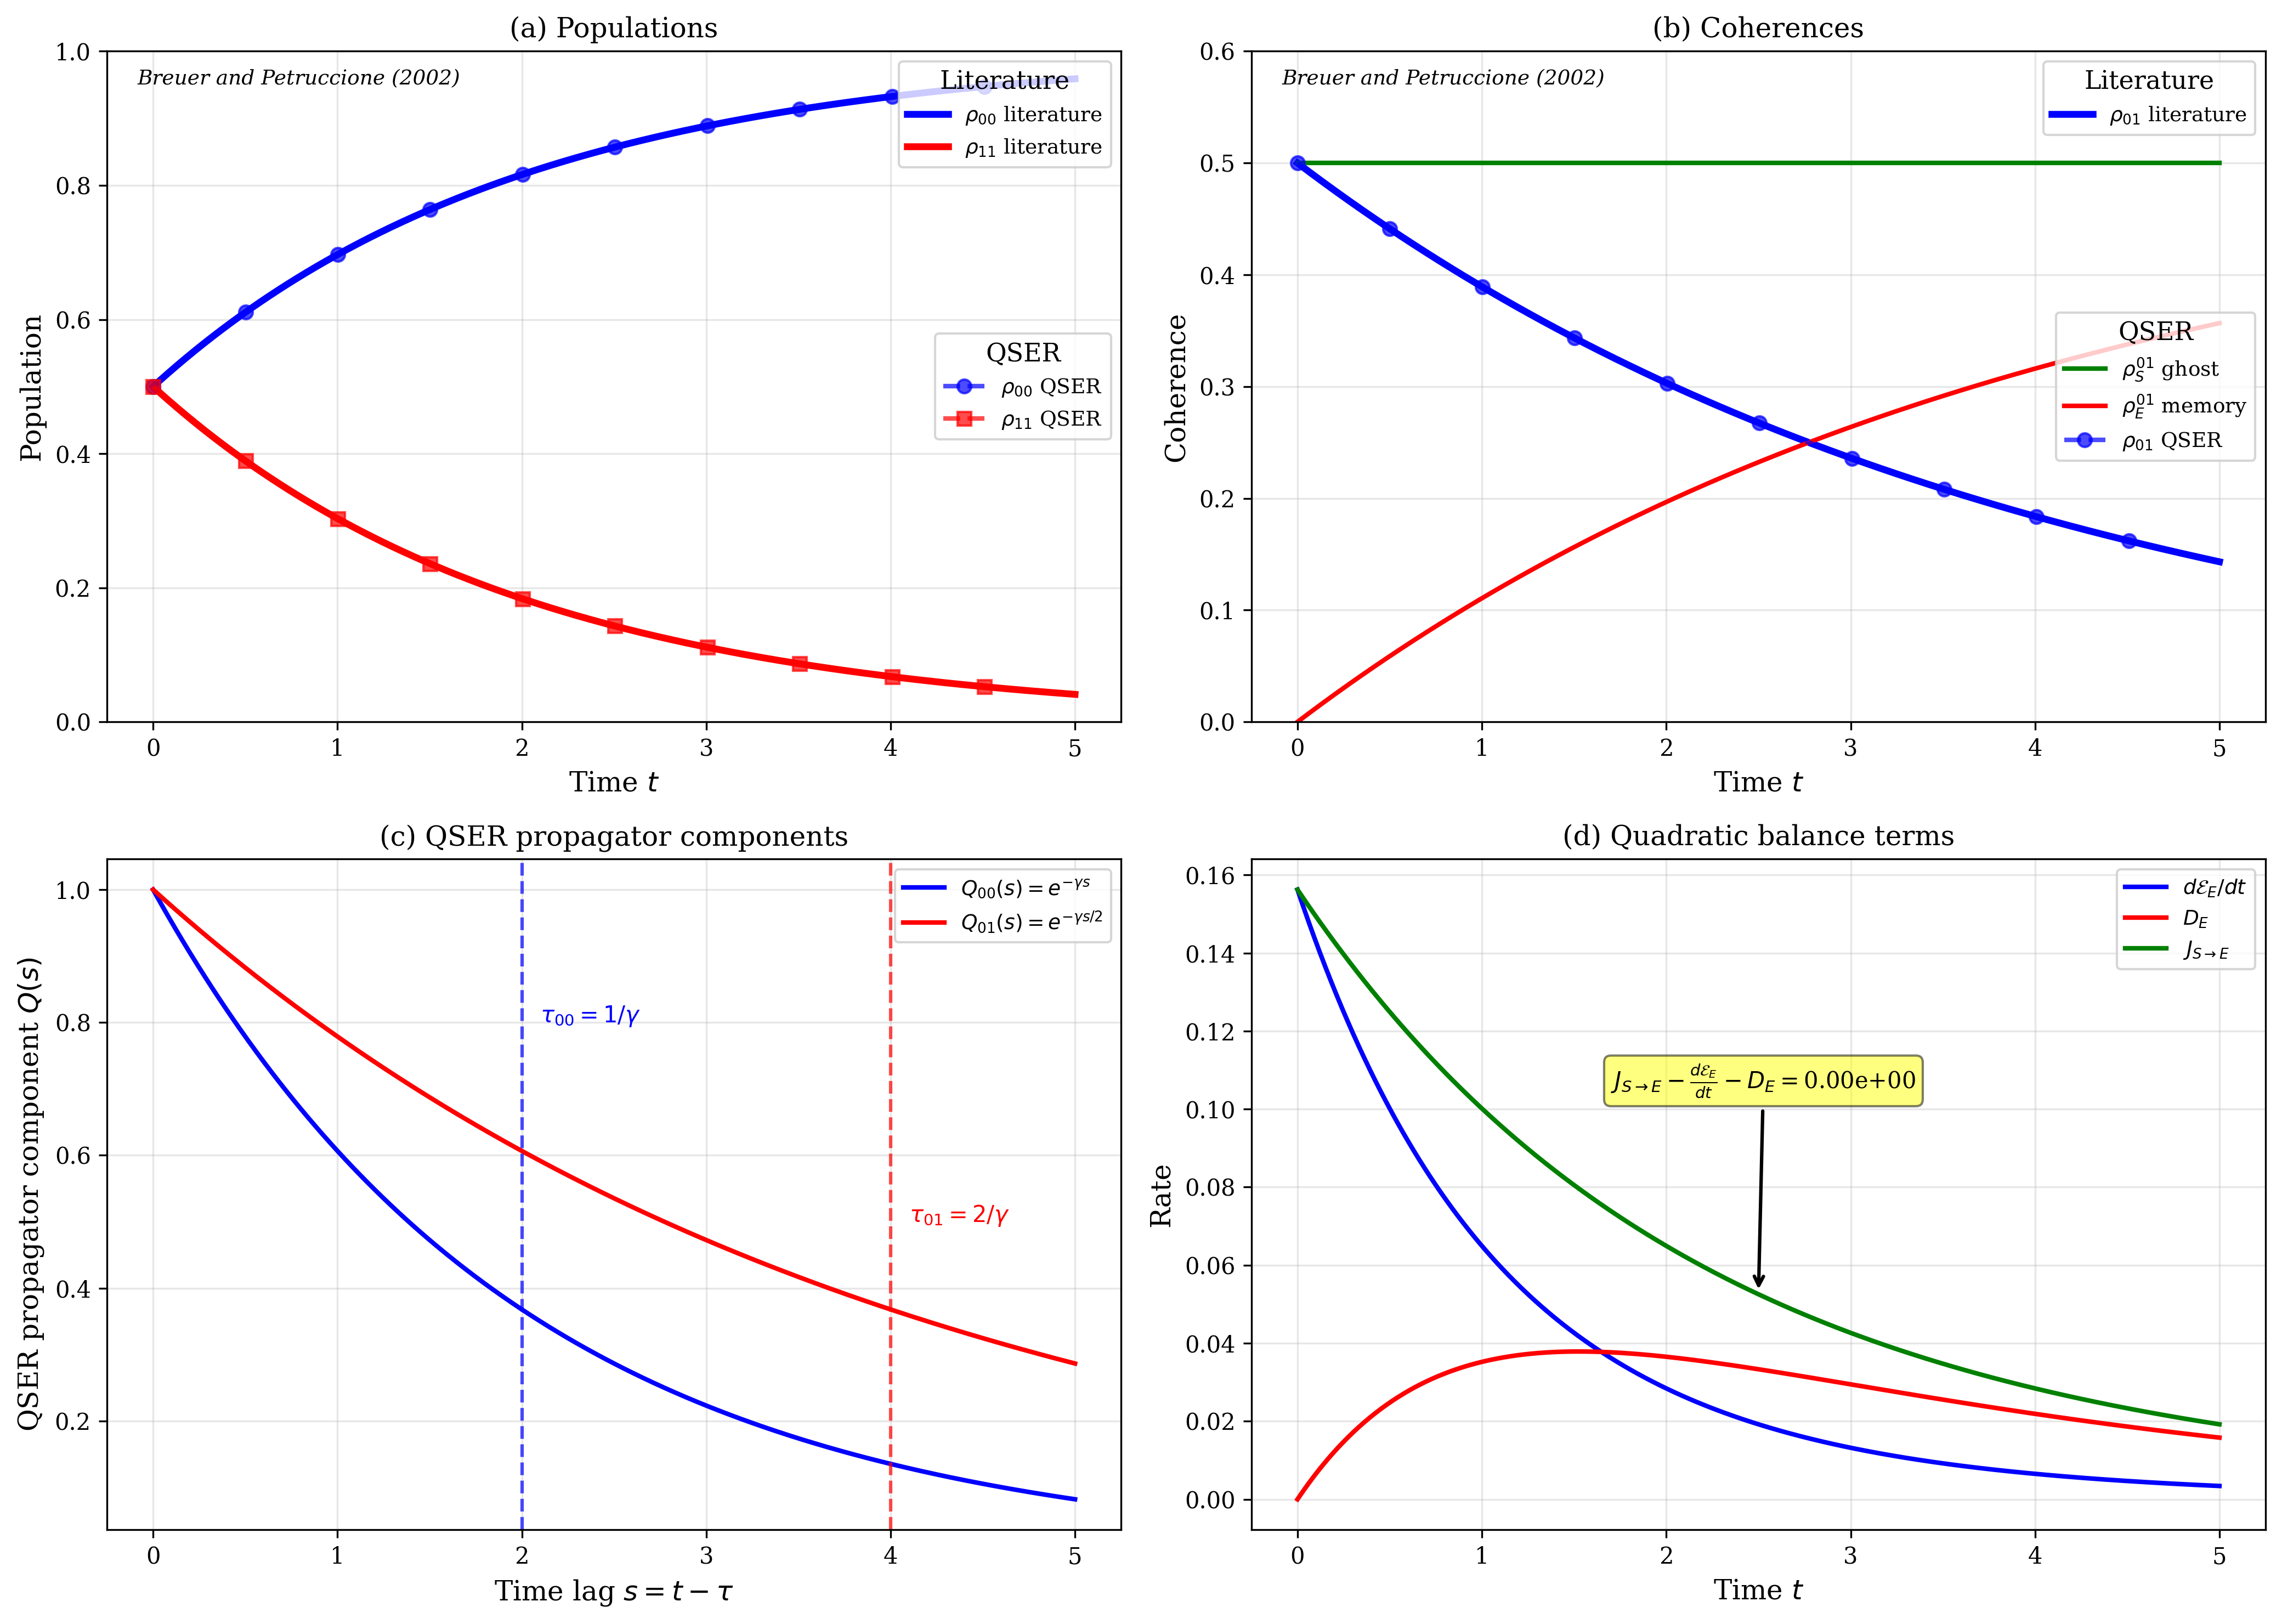

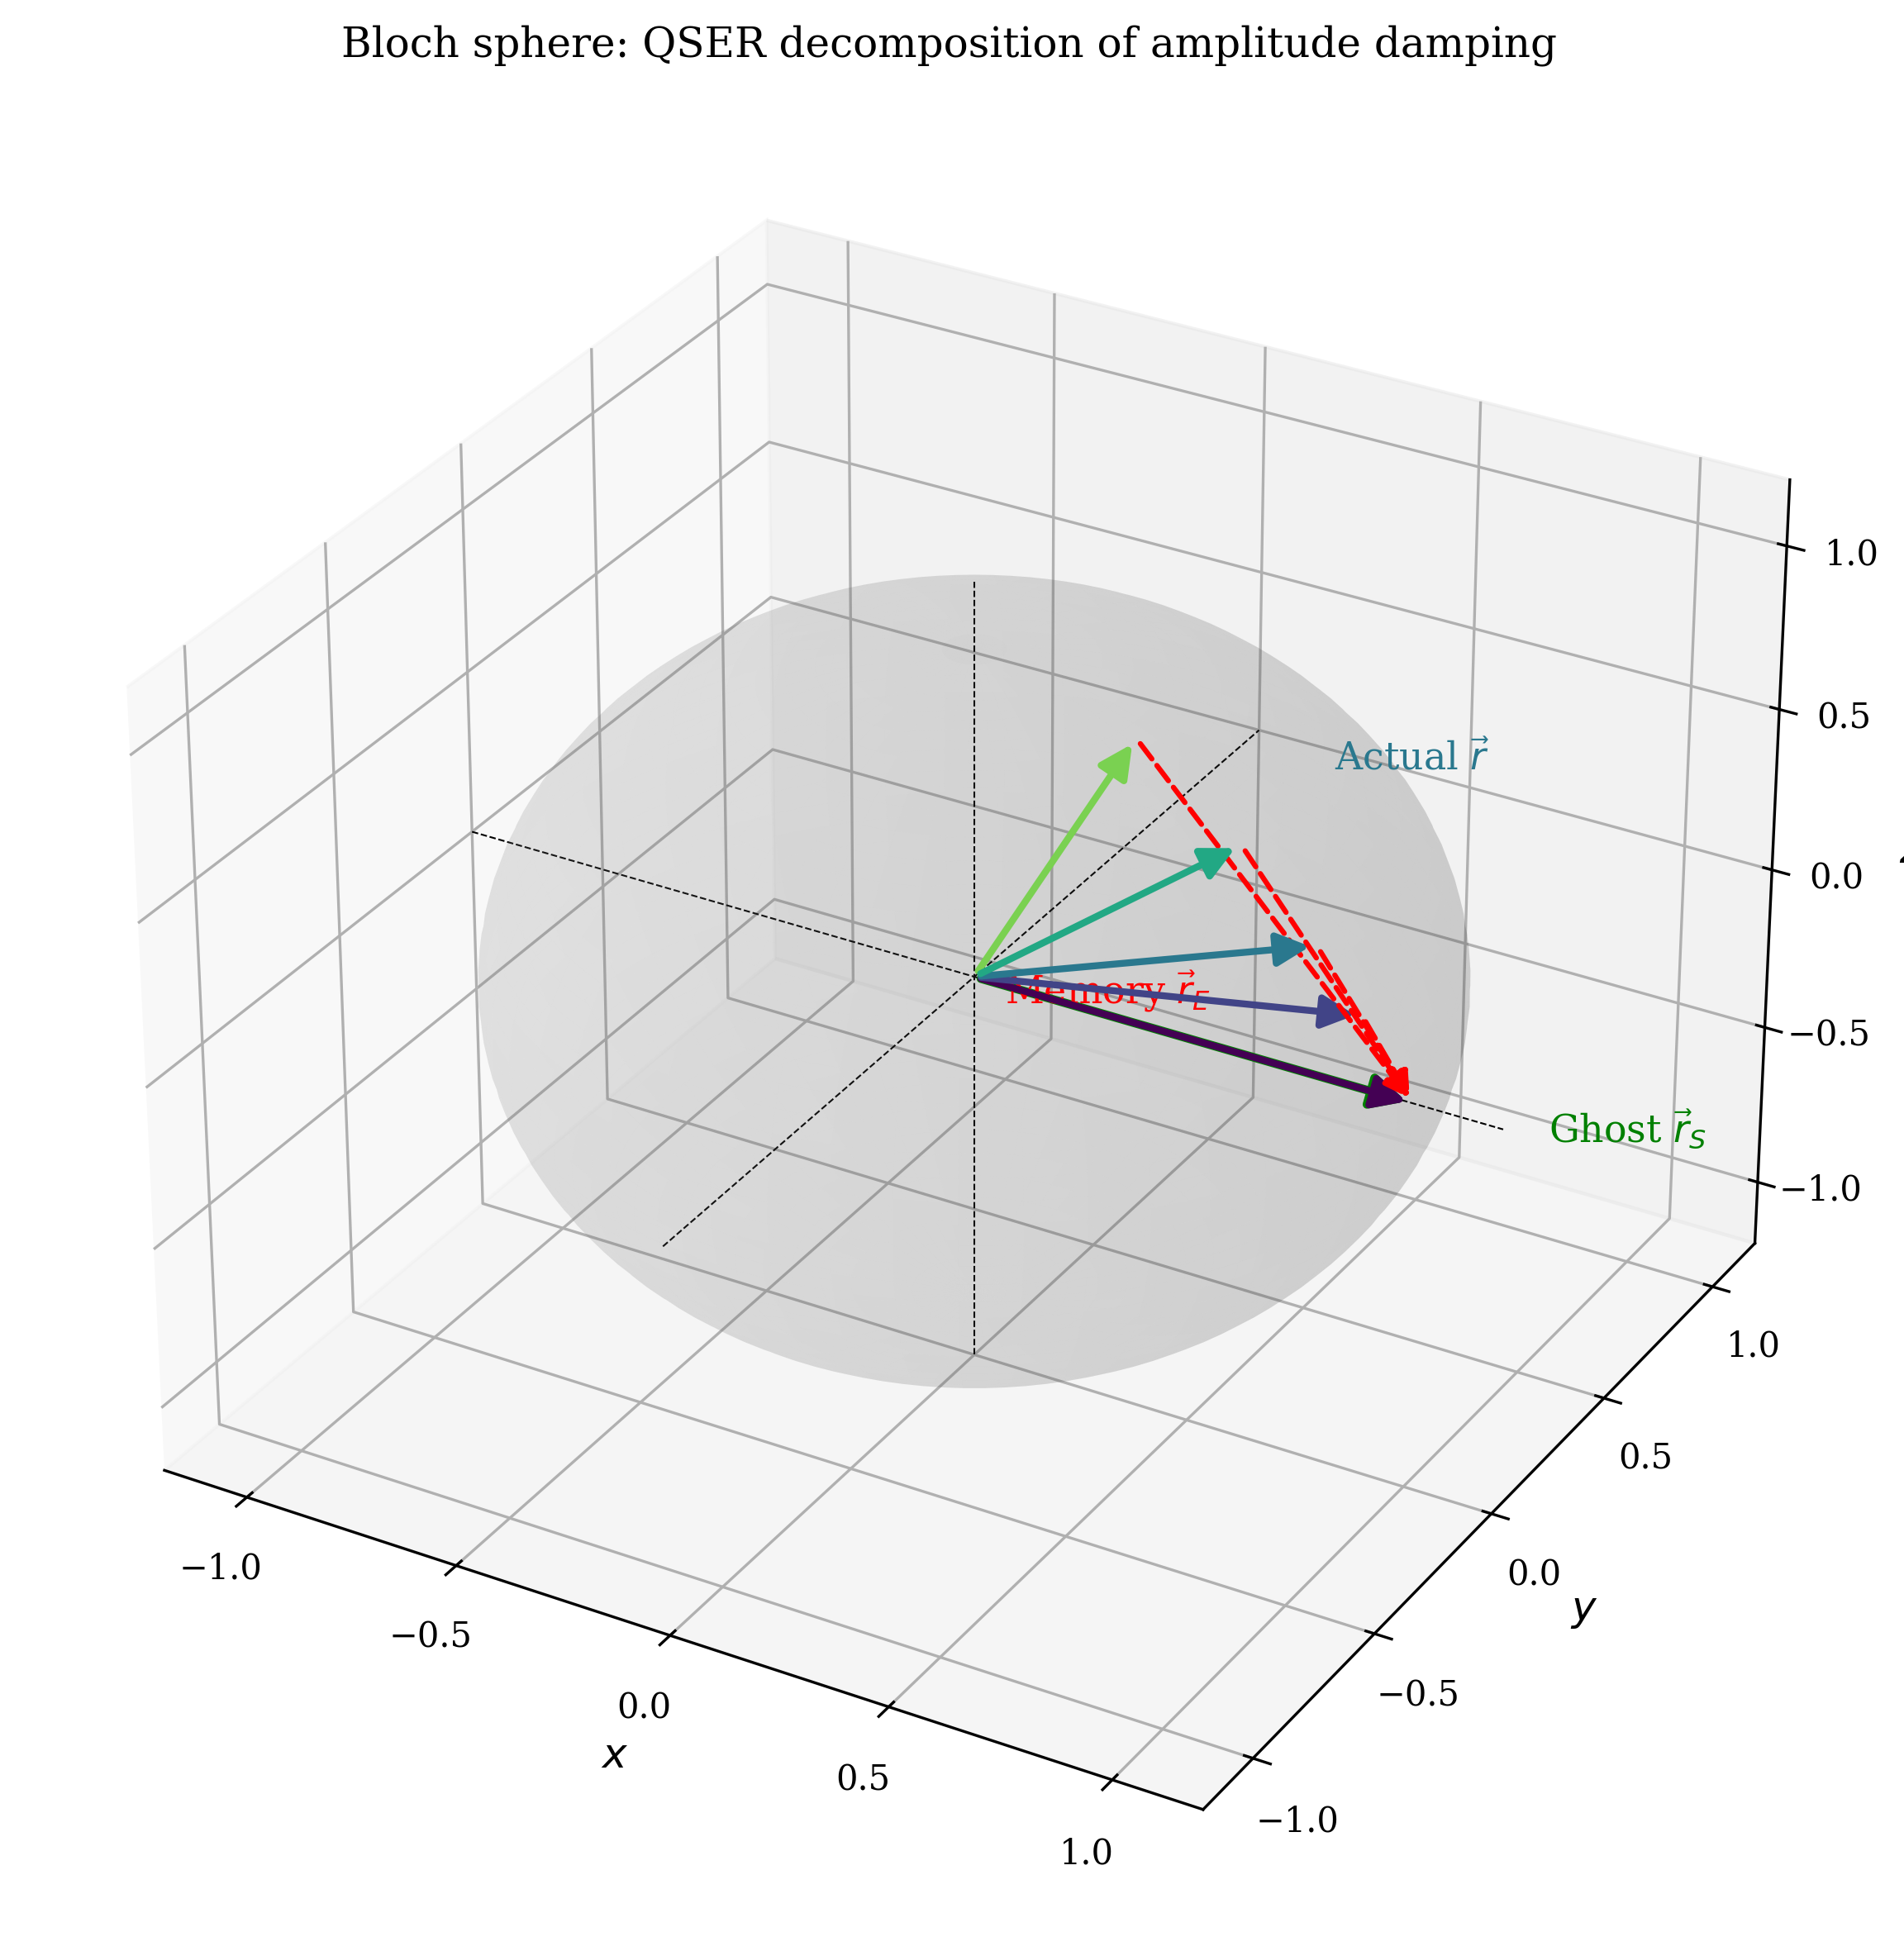

In [2]:

# Set style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.bbox': 'tight'
})

# Parameters
gamma = 0.5
t = np.linspace(0, 5, 500)
s = np.linspace(0, 5, 500)

# Initial state: pure superposition
rho_00_0 = 0.5
rho_11_0 = 0.5
rho_01_0 = 0.5
rho_10_0 = 0.5

# Literature solution for amplitude damping
# Convention: sigma_- = |1><0|, |0> = ground, |1> = excited
# Excited state rho_11 decays, ground state rho_00 grows
rho_11_lit = rho_11_0 * np.exp(-gamma * t)
rho_00_lit = rho_00_0 + rho_11_0 * (1 - np.exp(-gamma * t))
rho_01_lit = rho_01_0 * np.exp(-gamma * t / 2)
rho_10_lit = rho_10_0 * np.exp(-gamma * t / 2)

# QSER ghost (frozen since L_c = d/dt, so d(rho_S)/dt = 0)
rho_S_00 = rho_00_0 * np.ones_like(t)
rho_S_11 = rho_11_0 * np.ones_like(t)
rho_S_01 = rho_01_0 * np.ones_like(t)
rho_S_10 = rho_10_0 * np.ones_like(t)

# QSER environmental memory
# rho_E = rho_S - rho
rho_E_00 = rho_00_0 - rho_00_lit   # = -rho_11_0*(1 - e^{-gamma t})
rho_E_11 = rho_11_0 - rho_11_lit   # = +rho_11_0*(1 - e^{-gamma t})
rho_E_01 = rho_01_0 - rho_01_lit   # = rho_01_0*(1 - e^{-gamma t/2})
rho_E_10 = rho_10_0 - rho_10_lit   # = rho_10_0*(1 - e^{-gamma t/2})

# QSER reconstruction
rho_00_qser = rho_S_00 - rho_E_00
rho_11_qser = rho_S_11 - rho_E_11
rho_01_qser = rho_S_01 - rho_E_01
rho_10_qser = rho_S_10 - rho_E_10

# Time derivative of environmental memory
rho_E_dot_00 = -gamma * rho_11_0 * np.exp(-gamma * t)
rho_E_dot_11 = gamma * rho_11_0 * np.exp(-gamma * t)
rho_E_dot_01 = (gamma / 2) * rho_01_0 * np.exp(-gamma * t / 2)
rho_E_dot_10 = (gamma / 2) * rho_10_0 * np.exp(-gamma * t / 2)

# Quadratic balance identity terms
# dE_E/dt = Tr(rho_E_dot^dag L_c[rho_E]) with L_c = d/dt
dE_E_dt = (rho_E_dot_00 * rho_E_dot_00 + rho_E_dot_11 * rho_E_dot_11
           + rho_E_dot_01 * rho_E_dot_10 + rho_E_dot_10 * rho_E_dot_01)

# Dissipator acting on rho_E
# L_d[rho] = -gamma(sigma_- rho sigma_+ - 1/2{sigma_+ sigma_-, rho})
# With sigma_- = |1><0| and sigma_+ = |0><1|:
# L_d[rho]_00 = -gamma rho_11
# L_d[rho]_11 = +gamma rho_11
# L_d[rho]_01 = +(gamma/2) rho_01
# L_d[rho]_10 = +(gamma/2) rho_10
L_d_rho_E_00 = -gamma * rho_E_11
L_d_rho_E_11 = gamma * rho_E_11
L_d_rho_E_01 = (gamma / 2) * rho_E_01
L_d_rho_E_10 = (gamma / 2) * rho_E_10

# D_E = Tr(rho_E_dot^dag L_d[rho_E])
D_E = (rho_E_dot_00 * L_d_rho_E_00 + rho_E_dot_11 * L_d_rho_E_11
       + rho_E_dot_01 * L_d_rho_E_10 + rho_E_dot_10 * L_d_rho_E_01)

# Dissipator acting on rho_S
L_d_rho_S_00 = -gamma * rho_S_11
L_d_rho_S_11 = gamma * rho_S_11
L_d_rho_S_01 = (gamma / 2) * rho_S_01
L_d_rho_S_10 = (gamma / 2) * rho_S_10

# J_{S->E} = Tr(rho_E_dot^dag L_d[rho_S])
J_S_to_E = (rho_E_dot_00 * L_d_rho_S_00 + rho_E_dot_11 * L_d_rho_S_11
            + rho_E_dot_01 * L_d_rho_S_10 + rho_E_dot_10 * L_d_rho_S_01)

# Memory kernel components
Q_00_s = np.exp(-gamma * s)
Q_01_s = np.exp(-gamma * s / 2)

# Compute errors
error_rho_00 = np.max(np.abs(rho_00_qser - rho_00_lit))
error_rho_11 = np.max(np.abs(rho_11_qser - rho_11_lit))
error_rho_01 = np.max(np.abs(rho_01_qser - rho_01_lit))
error_rho_10 = np.max(np.abs(rho_10_qser - rho_10_lit))

continuity_residual = J_S_to_E - dE_E_dt - D_E
continuity_max_error = np.max(np.abs(continuity_residual))
continuity_mean_error = np.mean(np.abs(continuity_residual))

# Trace of environmental memory
trace_rho_E = rho_E_00 + rho_E_11

# Inheritance measure at final time
inheritance_final = np.linalg.norm([rho_E_00[-1], rho_E_11[-1], rho_E_01[-1], rho_E_10[-1]]) / np.linalg.norm([rho_S_00[-1], rho_S_11[-1], rho_S_01[-1], rho_S_10[-1]])

# Print values for manuscript
print("=" * 60)
print("QSER Analysis of Amplitude Damping: Numerical Values")
print("=" * 60)
print()
print("Parameters:")
print(f"  gamma = {gamma}")
print(f"  Initial state: rho_00(0) = {rho_00_0}, rho_11(0) = {rho_11_0}")
print(f"  Initial coherence: rho_01(0) = {rho_01_0}")
print()
print("Reconstruction Error (QSER vs Literature):")
print(f"  max |rho_00(QSER) - rho_00(Literature)| = {error_rho_00:.2e}")
print(f"  max |rho_11(QSER) - rho_11(Literature)| = {error_rho_11:.2e}")
print(f"  max |rho_01(QSER) - rho_01(Literature)| = {error_rho_01:.2e}")
print(f"  max |rho_10(QSER) - rho_10(Literature)| = {error_rho_10:.2e}")
print()
print("Quadratic Balance Identity Error:")
print(f"  max |J - dE/dt - D_E| = {continuity_max_error:.2e}")
print(f"  mean |J - dE/dt - D_E| = {continuity_mean_error:.2e}")
print()
print("Trace of Environmental Memory:")
print(f"  max |Tr(rho_E)| = {np.max(np.abs(trace_rho_E)):.2e}")
print()
print("Final State at t = 5:")
print(f"  rho_00(5) = {rho_00_lit[-1]:.6f}")
print(f"  rho_11(5) = {rho_11_lit[-1]:.6f}")
print(f"  rho_01(5) = {rho_01_lit[-1]:.6f}")
print(f"  rho_E^00(5) = {rho_E_00[-1]:.6f}")
print(f"  rho_E^11(5) = {rho_E_11[-1]:.6f}")
print(f"  rho_E^01(5) = {rho_E_01[-1]:.6f}")
print()
print("Inheritance Measure:")
print(f"  I(t_final) = {inheritance_final:.6f}")
print()
print("Memory Kernels:")
print(f"  Q_00(s) = exp(-gamma*s), tau_00 = {1/gamma:.4f}")
print(f"  Q_01(s) = exp(-gamma*s/2), tau_01 = {2/gamma:.4f}")
print()

# Figure 1: Four-panel subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel (a): Populations
ax = axes[0, 0]
ax.plot(t, rho_00_lit, 'b-', linewidth=3, label=r'$\rho_{00}$ literature')
ax.plot(t, rho_11_lit, 'r-', linewidth=3, label=r'$\rho_{11}$ literature')
ax.plot(t, rho_00_qser, 'b--', linewidth=2, marker='o', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{00}$ QSER')
ax.plot(t, rho_11_qser, 'r--', linewidth=2, marker='s', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{11}$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Population')
ax.set_title(r'(a) Populations')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines1, labels1 = ax.get_legend_handles_labels()
legend1 = ax.legend(lines1[:2], labels1[:2], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend1)
ax.legend(lines1[2:], labels1[2:], loc='center right', title='QSER', fontsize=9)

# Panel (b): Coherences
ax = axes[0, 1]
ax.plot(t, rho_01_lit, 'b-', linewidth=3, label=r'$\rho_{01}$ literature')
ax.plot(t, rho_S_01, 'g-', linewidth=2, label=r'$\rho_S^{01}$ ghost')
ax.plot(t, rho_E_01, 'r-', linewidth=2, label=r'$\rho_E^{01}$ memory')
ax.plot(t, rho_01_qser, 'b--', linewidth=2, marker='o', markersize=6, markevery=50, alpha=0.7, label=r'$\rho_{01}$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Coherence')
ax.set_title(r'(b) Coherences')
ax.set_ylim(0, 0.6)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines2, labels2 = ax.get_legend_handles_labels()
legend2 = ax.legend(lines2[:1], labels2[:1], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend2)
ax.legend(lines2[1:], labels2[1:], loc='center right', title='QSER', fontsize=9)

# Panel (c): Memory kernels
ax = axes[1, 0]
ax.plot(s, Q_00_s, 'b-', linewidth=2, label=r'$Q_{00}(s) = e^{-\gamma s}$')
ax.plot(s, Q_01_s, 'r-', linewidth=2, label=r'$Q_{01}(s) = e^{-\gamma s/2}$')
ax.set_xlabel(r'Time lag $s = t - \tau$')
ax.set_ylabel(r'QSER propagator component $Q(s)$')
ax.set_title(r'(c) QSER propagator components')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

tau_00 = 1 / gamma
tau_01 = 2 / gamma
ax.axvline(tau_00, color='b', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(tau_01, color='r', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(tau_00 + 0.1, 0.8, r'$\tau_{00} = 1/\gamma$', color='b', fontsize=10)
ax.text(tau_01 + 0.1, 0.5, r'$\tau_{01} = 2/\gamma$', color='r', fontsize=10)

# Panel (d): Quadratic balance terms
ax = axes[1, 1]
ax.plot(t, dE_E_dt, 'b-', linewidth=2, label=r'$d\mathcal{E}_E/dt$')
ax.plot(t, D_E, 'r-', linewidth=2, label=r'$D_E$')
ax.plot(t, J_S_to_E, 'g-', linewidth=2, label=r'$J_{S \to E}$')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Rate')
ax.set_title(r'(d) Quadratic balance terms')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

residual = J_S_to_E - dE_E_dt - D_E
t_annotate = 2.5
idx_annotate = np.argmin(np.abs(t - t_annotate))

residual_value = residual[idx_annotate]
ax.annotate(
    r'$J_{S \to E} - \frac{d\mathcal{E}_E}{dt} - D_E = $' + f'{residual_value:.2e}',
    xy=(t_annotate, J_S_to_E[idx_annotate]),
    xytext=(t_annotate - 0.8, J_S_to_E[idx_annotate] * 2),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig3_amplitude_damping_analysis.pdf'))
#plt.savefig(os.path.join(save_path, 'fig3_amplitude_damping_analysis.png'))
plt.show()

# Figure 2: Bloch sphere
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')

ax.plot([-1.2, 1.2], [0, 0], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], 'k--', linewidth=0.5)

arrow_ghost = Arrow3D([0, 1], [0, 0], [0, 0], mutation_scale=20, lw=2.5, arrowstyle='-|>', color='green')
ax.add_artist(arrow_ghost)

times_plot = [0, 0.5, 1, 2, 4]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(times_plot)))

for idx, ti in enumerate(times_plot):
    r_x = np.exp(-gamma * ti / 2)
    r_z = 1 - np.exp(-gamma * ti)   # <-- corrected: goes to +1 (north pole)
    arrow_actual = Arrow3D([0, r_x], [0, 0], [0, r_z], mutation_scale=20, lw=2, arrowstyle='-|>', color=colors[idx])
    ax.add_artist(arrow_actual)

for idx, ti in enumerate(times_plot):
    r_x_actual = np.exp(-gamma * ti / 2)
    r_z_actual = 1 - np.exp(-gamma * ti)   # <-- corrected
    r_x_ghost = 1
    r_z_ghost = 0
    arrow_memory = Arrow3D([r_x_actual, r_x_ghost], [0, 0], [r_z_actual, r_z_ghost], mutation_scale=15, lw=1.5, arrowstyle='-|>', color='red', linestyle='--')
    ax.add_artist(arrow_memory)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$z$')
ax.set_title(r'Bloch sphere: QSER decomposition of amplitude damping')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

ax.text(1.3, 0, 0, r'Ghost $\vec{r}_S$', color='green', fontsize=11)
ax.text(0.6, 0.4, 0.6, r'Actual $\vec{r}$', color=colors[2], fontsize=11)
ax.text(0.3, -0.4, 0.3, r'Memory $\vec{r}_E$', color='red', fontsize=11)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig4_amplitude_damping_bloch.pdf'))
#plt.savefig(os.path.join(save_path, 'fig4_amplitude_damping_bloch.png'))
plt.show()



## Case 3: Hamiltonian with Amplitude damping

QSER Analysis of Hamiltonian with Amplitude Damping

Parameters:
  gamma = 0.5
  omega = 2.0
  Initial state: rho_00(0) = 0.5, rho_11(0) = 0.5
  Initial coherence: rho_01(0) = 0.5

Reconstruction Error (QSER vs Literature):
  max |rho_00(QSER) - rho_00(Literature)| = 0.00e+00
  max |rho_11(QSER) - rho_11(Literature)| = 2.78e-17
  max |rho_01(QSER) - rho_01(Literature)| = 6.21e-17
  max |rho_10(QSER) - rho_10(Literature)| = 6.21e-17

Quadratic Balance Identity Error:
  max |J - dE/dt - D_E| = 1.28e-16
  mean |J - dE/dt - D_E| = 2.19e-17

Trace of Environmental Memory:
  max |Tr(rho_E)| = 5.55e-17

Final State at t = 5:
  rho_00(5) = 0.958958
  rho_11(5) = 0.041042
  |rho_01(5)| = 0.143252
  Re(rho_01(5)) = -0.120199
  Im(rho_01(5)) = 0.077932
  |rho_S^01(5)| = 0.500000
  |rho_E^01(5)| = 0.356748

Inheritance Measure:
  I(t_final) = 0.822084

Memory Kernels:
  Q_00(s) = exp(-gamma*s), tau_00 = 2.0000
  Q_01(s) = exp(-i*omega*s)*exp(-gamma*s/2), tau_01 = 4.0000



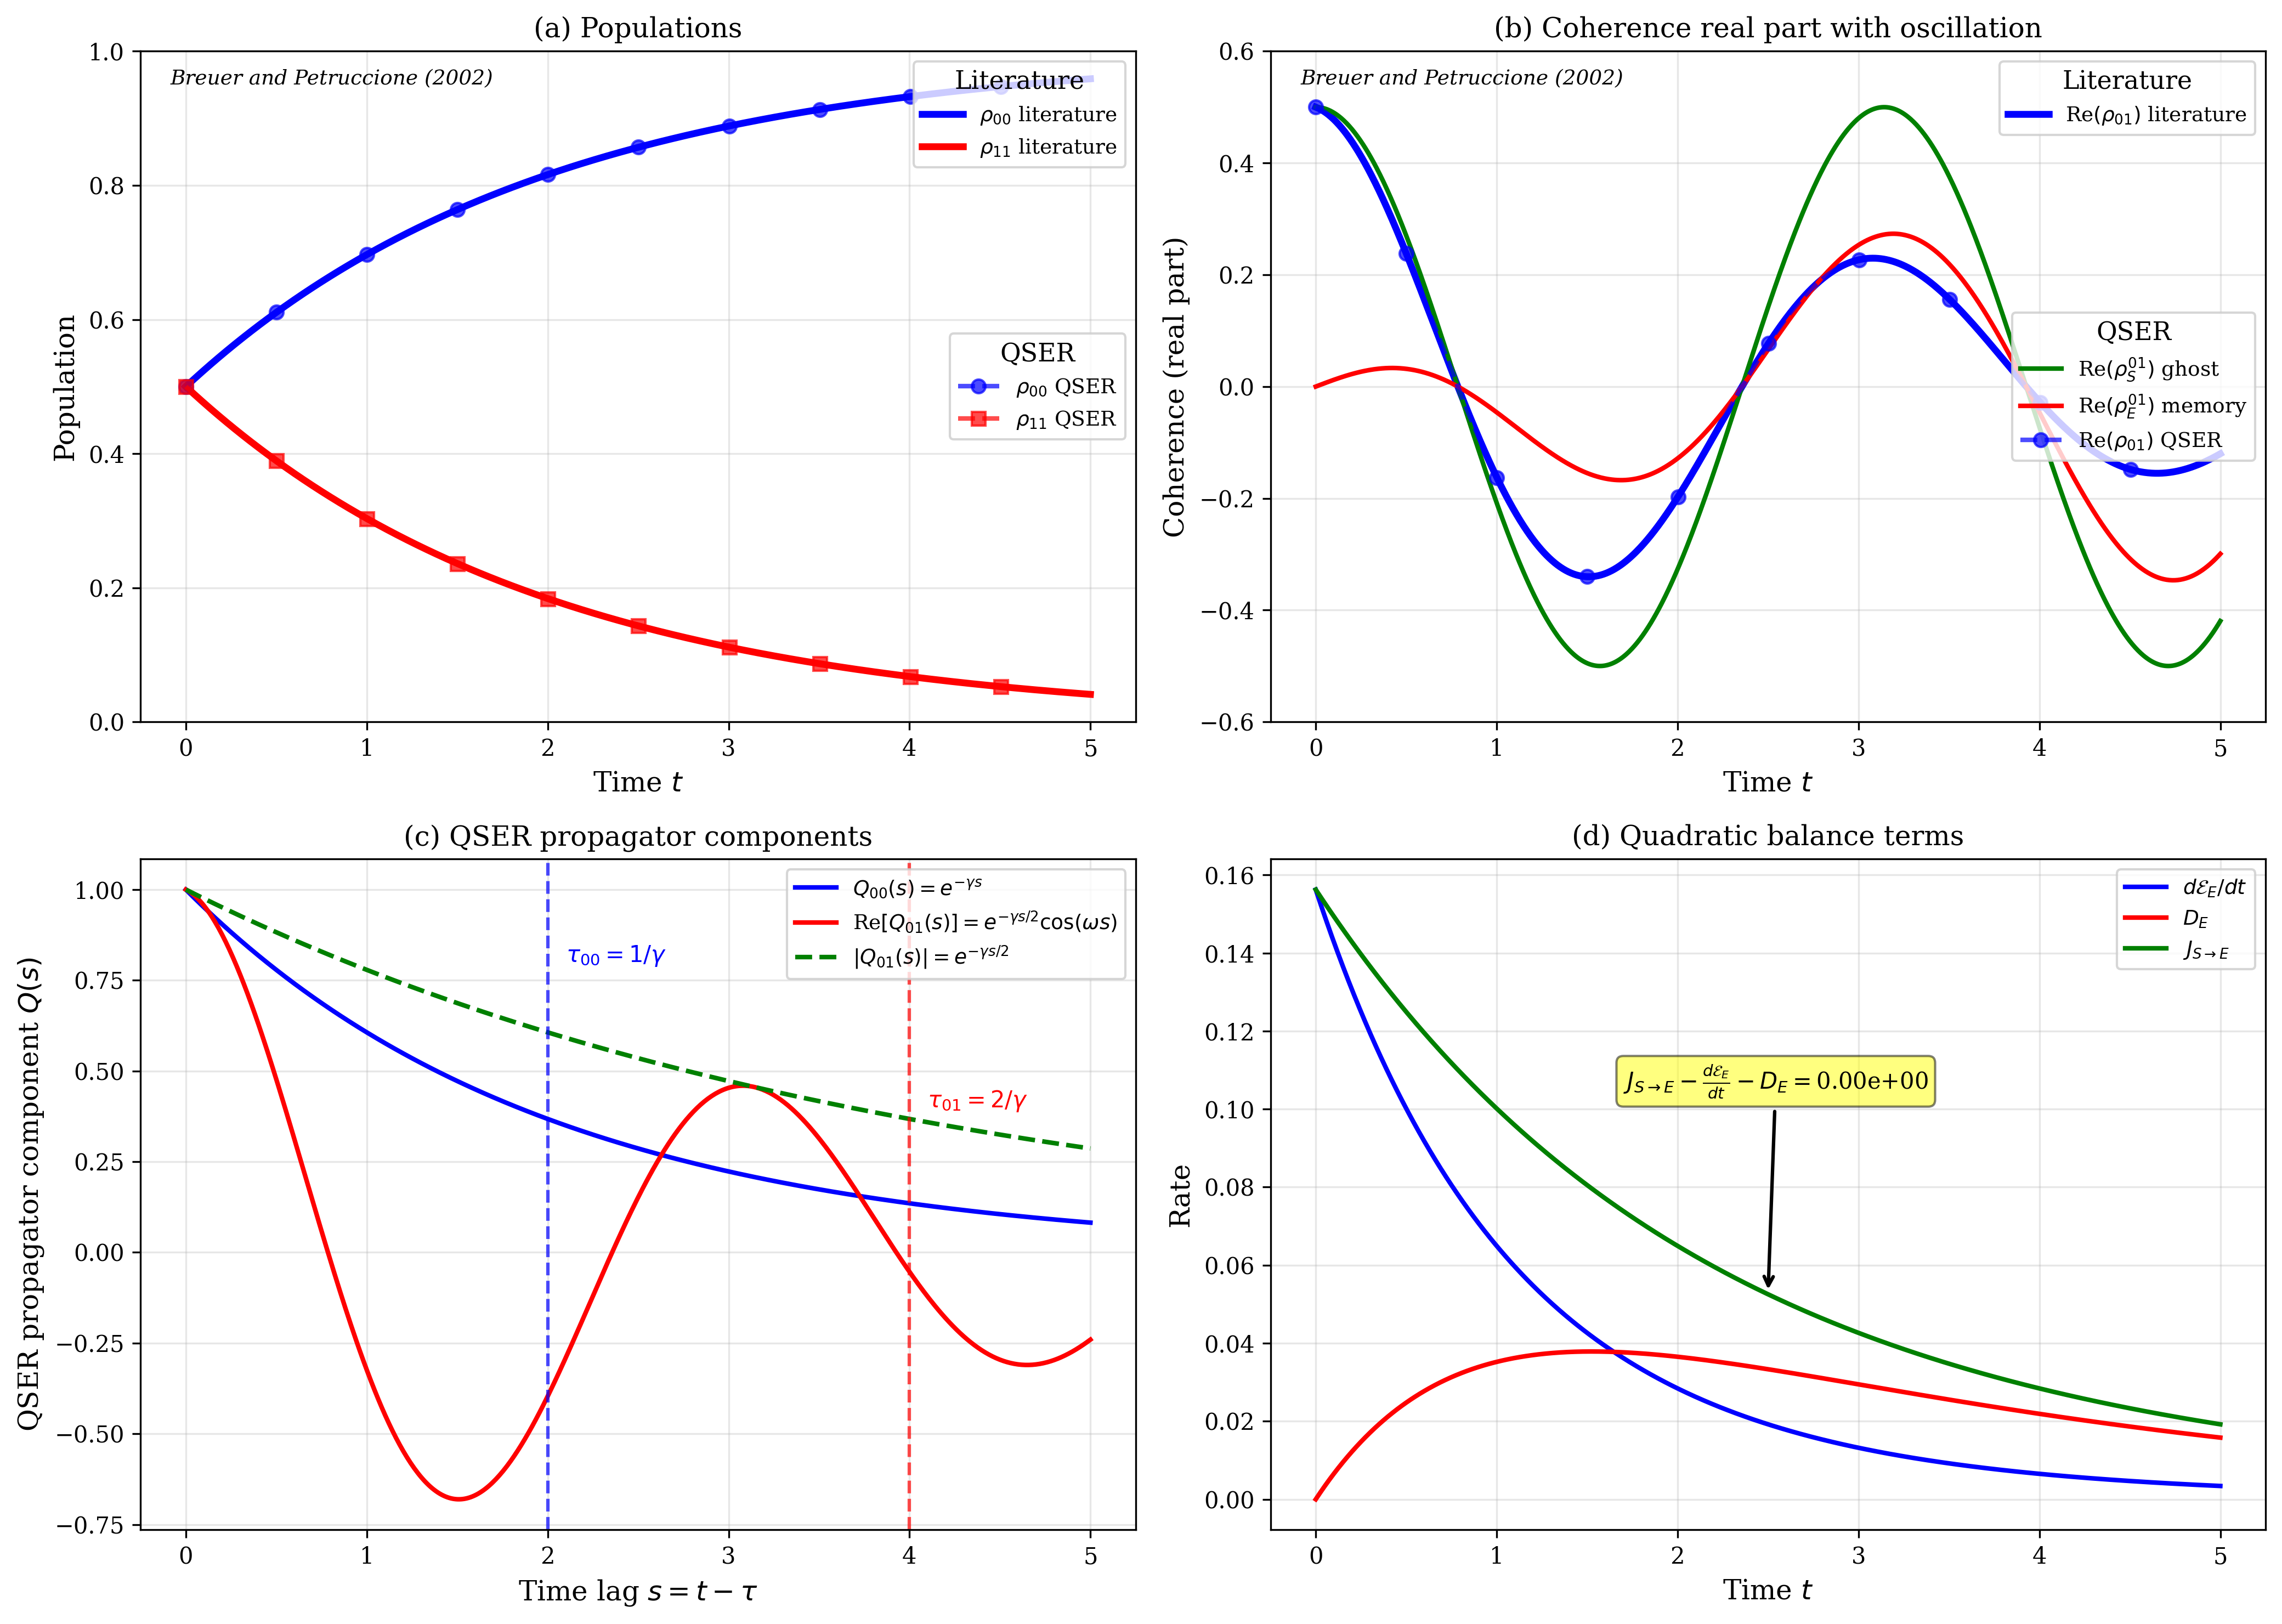

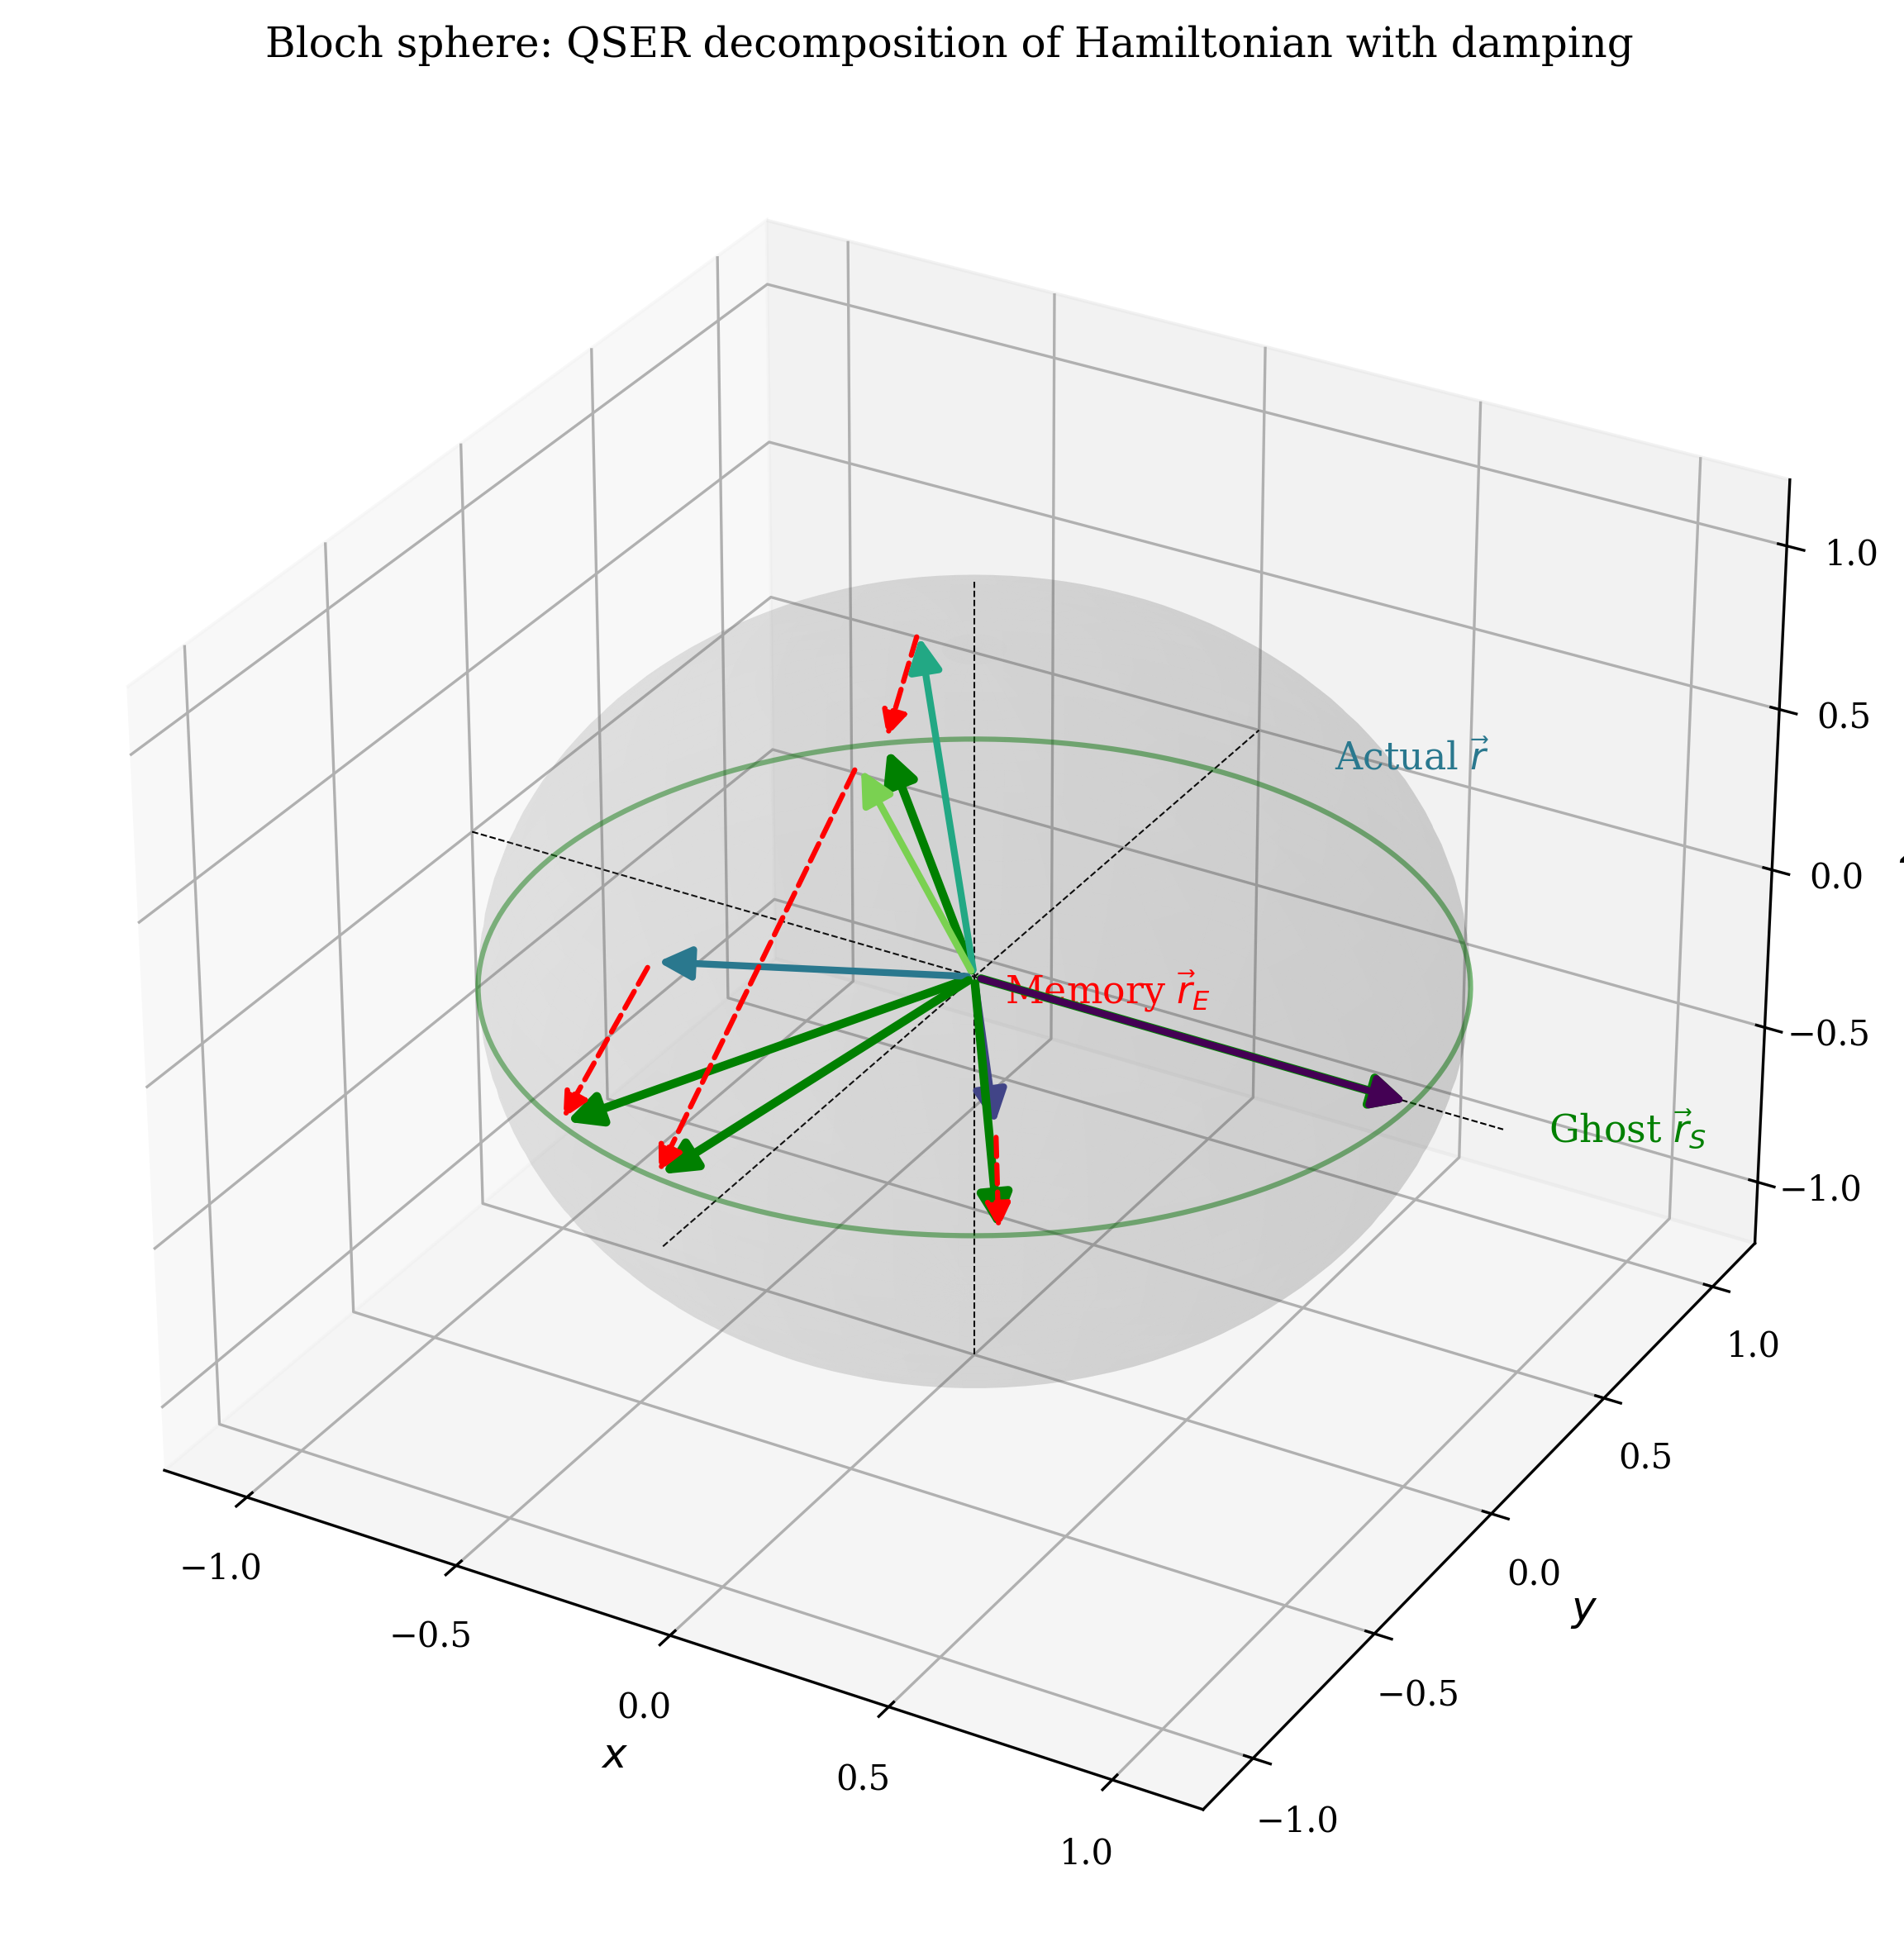

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import os


# Set style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.bbox': 'tight'
})

# Parameters
gamma = 0.5
omega = 2.0
t = np.linspace(0, 5, 1000)
s = np.linspace(0, 5, 500)

# Initial state: pure superposition
rho_00_0 = 0.5
rho_11_0 = 0.5
rho_01_0 = 0.5
rho_10_0 = 0.5

# Literature solution for Hamiltonian + amplitude damping
# Convention: sigma_- = |0><1|, |0> = ground, |1> = excited
# Excited state rho_11 decays, ground state rho_00 grows
rho_11_lit = rho_11_0 * np.exp(-gamma * t)
rho_00_lit = rho_00_0 + rho_11_0 * (1 - np.exp(-gamma * t))
rho_01_lit = rho_01_0 * np.exp(-1j * omega * t) * np.exp(-gamma * t / 2)
rho_10_lit = rho_10_0 * np.exp(1j * omega * t) * np.exp(-gamma * t / 2)

# QSER ghost (evolves unitarily since H = hbar*omega*sigma_z/2)
rho_S_00 = rho_00_0 * np.ones_like(t)
rho_S_11 = rho_11_0 * np.ones_like(t)
rho_S_01 = rho_01_0 * np.exp(-1j * omega * t)
rho_S_10 = rho_10_0 * np.exp(1j * omega * t)

# QSER environmental memory
# rho_E = rho_S - rho
rho_E_00 = rho_00_0 - rho_00_lit   # = -rho_11_0*(1 - e^{-gamma t})
rho_E_11 = rho_11_0 - rho_11_lit   # = +rho_11_0*(1 - e^{-gamma t})
rho_E_01 = rho_01_0 * np.exp(-1j * omega * t) * (1 - np.exp(-gamma * t / 2))
rho_E_10 = rho_10_0 * np.exp(1j * omega * t) * (1 - np.exp(-gamma * t / 2))

# QSER reconstruction
rho_00_qser = rho_S_00 - rho_E_00
rho_11_qser = rho_S_11 - rho_E_11
rho_01_qser = rho_S_01 - rho_E_01
rho_10_qser = rho_S_10 - rho_E_10

# Time derivative of environmental memory
rho_E_dot_00 = -gamma * rho_11_0 * np.exp(-gamma * t)
rho_E_dot_11 = gamma * rho_11_0 * np.exp(-gamma * t)
rho_E_dot_01 = rho_01_0 * np.exp(-1j * omega * t) * (-1j * omega * (1 - np.exp(-gamma * t / 2)) + (gamma / 2) * np.exp(-gamma * t / 2))
rho_E_dot_10 = rho_10_0 * np.exp(1j * omega * t) * (1j * omega * (1 - np.exp(-gamma * t / 2)) + (gamma / 2) * np.exp(-gamma * t / 2))

# Quadratic balance identity terms
# L_c[rho_E] = d(rho_E)/dt + i/hbar [H, rho_E]
# For H = hbar*omega*sigma_z/2:
L_c_rho_E_00 = rho_E_dot_00
L_c_rho_E_11 = rho_E_dot_11
L_c_rho_E_01 = rho_E_dot_01 + 1j * omega * rho_E_01
L_c_rho_E_10 = rho_E_dot_10 - 1j * omega * rho_E_10

# CORRECTED: Tr(rho_E_dot^dag L_c[rho_E]) with matching indices
dE_E_dt = (np.conj(rho_E_dot_00) * L_c_rho_E_00 + np.conj(rho_E_dot_11) * L_c_rho_E_11
           + np.conj(rho_E_dot_01) * L_c_rho_E_01 + np.conj(rho_E_dot_10) * L_c_rho_E_10)

# Dissipator acting on rho_E
# With sigma_- = |0><1| and sigma_+ = |1><0|:
# L_d[rho]_00 = -gamma rho_11
# L_d[rho]_11 = +gamma rho_11
# L_d[rho]_01 = +(gamma/2) rho_01
# L_d[rho]_10 = +(gamma/2) rho_10
L_d_rho_E_00 = -gamma * rho_E_11
L_d_rho_E_11 = gamma * rho_E_11
L_d_rho_E_01 = (gamma / 2) * rho_E_01
L_d_rho_E_10 = (gamma / 2) * rho_E_10

# CORRECTED: D_E = Tr(rho_E_dot^dag L_d[rho_E]) with matching indices
D_E = (np.conj(rho_E_dot_00) * L_d_rho_E_00 + np.conj(rho_E_dot_11) * L_d_rho_E_11
       + np.conj(rho_E_dot_01) * L_d_rho_E_01 + np.conj(rho_E_dot_10) * L_d_rho_E_10)

# Dissipator acting on rho_S
L_d_rho_S_00 = -gamma * rho_S_11
L_d_rho_S_11 = gamma * rho_S_11
L_d_rho_S_01 = (gamma / 2) * rho_S_01
L_d_rho_S_10 = (gamma / 2) * rho_S_10

# CORRECTED: J_{S->E} = Tr(rho_E_dot^dag L_d[rho_S]) with matching indices
J_S_to_E = (np.conj(rho_E_dot_00) * L_d_rho_S_00 + np.conj(rho_E_dot_11) * L_d_rho_S_11
            + np.conj(rho_E_dot_01) * L_d_rho_S_01 + np.conj(rho_E_dot_10) * L_d_rho_S_10)

# Memory kernel components
Q_00_s = np.exp(-gamma * s)
Q_01_s = np.exp(-1j * omega * s) * np.exp(-gamma * s / 2)

# Compute errors
error_rho_00 = np.max(np.abs(rho_00_qser - rho_00_lit))
error_rho_11 = np.max(np.abs(rho_11_qser - rho_11_lit))
error_rho_01 = np.max(np.abs(rho_01_qser - rho_01_lit))
error_rho_10 = np.max(np.abs(rho_10_qser - rho_10_lit))

continuity_residual = np.real(J_S_to_E - dE_E_dt - D_E)
continuity_max_error = np.max(np.abs(continuity_residual))
continuity_mean_error = np.mean(np.abs(continuity_residual))

# Trace of environmental memory
trace_rho_E = rho_E_00 + rho_E_11

# Inheritance measure at final time
inheritance_final = np.linalg.norm([rho_E_00[-1], rho_E_11[-1], np.abs(rho_E_01[-1]), np.abs(rho_E_10[-1])]) / np.linalg.norm([rho_S_00[-1], rho_S_11[-1], np.abs(rho_S_01[-1]), np.abs(rho_S_10[-1])])

# Print values for manuscript
print("=" * 60)
print("QSER Analysis of Hamiltonian with Amplitude Damping")
print("=" * 60)
print()
print("Parameters:")
print(f"  gamma = {gamma}")
print(f"  omega = {omega}")
print(f"  Initial state: rho_00(0) = {rho_00_0}, rho_11(0) = {rho_11_0}")
print(f"  Initial coherence: rho_01(0) = {rho_01_0}")
print()
print("Reconstruction Error (QSER vs Literature):")
print(f"  max |rho_00(QSER) - rho_00(Literature)| = {error_rho_00:.2e}")
print(f"  max |rho_11(QSER) - rho_11(Literature)| = {error_rho_11:.2e}")
print(f"  max |rho_01(QSER) - rho_01(Literature)| = {error_rho_01:.2e}")
print(f"  max |rho_10(QSER) - rho_10(Literature)| = {error_rho_10:.2e}")
print()
print("Quadratic Balance Identity Error:")
print(f"  max |J - dE/dt - D_E| = {continuity_max_error:.2e}")
print(f"  mean |J - dE/dt - D_E| = {continuity_mean_error:.2e}")
print()
print("Trace of Environmental Memory:")
print(f"  max |Tr(rho_E)| = {np.max(np.abs(trace_rho_E)):.2e}")
print()
print("Final State at t = 5:")
print(f"  rho_00(5) = {np.real(rho_00_lit[-1]):.6f}")
print(f"  rho_11(5) = {np.real(rho_11_lit[-1]):.6f}")
print(f"  |rho_01(5)| = {np.abs(rho_01_lit[-1]):.6f}")
print(f"  Re(rho_01(5)) = {np.real(rho_01_lit[-1]):.6f}")
print(f"  Im(rho_01(5)) = {np.imag(rho_01_lit[-1]):.6f}")
print(f"  |rho_S^01(5)| = {np.abs(rho_S_01[-1]):.6f}")
print(f"  |rho_E^01(5)| = {np.abs(rho_E_01[-1]):.6f}")
print()
print("Inheritance Measure:")
print(f"  I(t_final) = {inheritance_final:.6f}")
print()
print("Memory Kernels:")
print(f"  Q_00(s) = exp(-gamma*s), tau_00 = {1/gamma:.4f}")
print(f"  Q_01(s) = exp(-i*omega*s)*exp(-gamma*s/2), tau_01 = {2/gamma:.4f}")
print()

# Figure 1: Four-panel subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel (a): Populations
ax = axes[0, 0]
ax.plot(t, np.real(rho_00_lit), 'b-', linewidth=3, label=r'$\rho_{00}$ literature')
ax.plot(t, np.real(rho_11_lit), 'r-', linewidth=3, label=r'$\rho_{11}$ literature')
ax.plot(t, np.real(rho_00_qser), 'b--', linewidth=2, marker='o', markersize=6, markevery=100, alpha=0.7, label=r'$\rho_{00}$ QSER')
ax.plot(t, np.real(rho_11_qser), 'r--', linewidth=2, marker='s', markersize=6, markevery=100, alpha=0.7, label=r'$\rho_{11}$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Population')
ax.set_title(r'(a) Populations')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines1, labels1 = ax.get_legend_handles_labels()
legend1 = ax.legend(lines1[:2], labels1[:2], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend1)
ax.legend(lines1[2:], labels1[2:], loc='center right', title='QSER', fontsize=9)

# Panel (b): Coherences (real part)
ax = axes[0, 1]
ax.plot(t, np.real(rho_01_lit), 'b-', linewidth=3, label=r'Re$(\rho_{01})$ literature')
ax.plot(t, np.real(rho_S_01), 'g-', linewidth=2, label=r'Re$(\rho_S^{01})$ ghost')
ax.plot(t, np.real(rho_E_01), 'r-', linewidth=2, label=r'Re$(\rho_E^{01})$ memory')
ax.plot(t, np.real(rho_01_qser), 'b--', linewidth=2, marker='o', markersize=6, markevery=100, alpha=0.7, label=r'Re$(\rho_{01})$ QSER')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Coherence (real part)')
ax.set_title(r'(b) Coherence real part with oscillation')
ax.set_ylim(-0.6, 0.6)
ax.grid(True, alpha=0.3)

ax.text(0.03, 0.95, 'Breuer and Petruccione (2002)', transform=ax.transAxes, fontsize=9, style='italic', color='black')

lines2, labels2 = ax.get_legend_handles_labels()
legend2 = ax.legend(lines2[:1], labels2[:1], loc='upper right', title='Literature', fontsize=9)
ax.add_artist(legend2)
ax.legend(lines2[1:], labels2[1:], loc='center right', title='QSER', fontsize=9)

# Panel (c): Memory kernels
ax = axes[1, 0]
ax.plot(s, np.real(Q_00_s), 'b-', linewidth=2, label=r'$Q_{00}(s) = e^{-\gamma s}$')
ax.plot(s, np.real(Q_01_s), 'r-', linewidth=2, label=r'Re$[Q_{01}(s)] = e^{-\gamma s/2}\cos(\omega s)$')
ax.plot(s, np.abs(Q_01_s), 'g--', linewidth=2, label=r'$|Q_{01}(s)| = e^{-\gamma s/2}$')
ax.set_xlabel(r'Time lag $s = t - \tau$')
ax.set_ylabel(r'QSER propagator component $Q(s)$')
ax.set_title(r'(c) QSER propagator components')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

tau_00 = 1 / gamma
tau_01 = 2 / gamma
ax.axvline(tau_00, color='b', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(tau_01, color='r', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(tau_00 + 0.1, 0.8, r'$\tau_{00} = 1/\gamma$', color='b', fontsize=10)
ax.text(tau_01 + 0.1, 0.4, r'$\tau_{01} = 2/\gamma$', color='r', fontsize=10)

# Panel (d): Quadratic balance terms
ax = axes[1, 1]
ax.plot(t, np.real(dE_E_dt), 'b-', linewidth=2, label=r'$d\mathcal{E}_E/dt$')
ax.plot(t, np.real(D_E), 'r-', linewidth=2, label=r'$D_E$')
ax.plot(t, np.real(J_S_to_E), 'g-', linewidth=2, label=r'$J_{S \to E}$')
ax.set_xlabel(r'Time $t$')
ax.set_ylabel(r'Rate')
ax.set_title(r'(d) Quadratic balance terms')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

residual = np.real(J_S_to_E - dE_E_dt - D_E)
t_annotate = 2.5
idx_annotate = np.argmin(np.abs(t - t_annotate))

residual_value = residual[idx_annotate]
ax.annotate(
    r'$J_{S \to E} - \frac{d\mathcal{E}_E}{dt} - D_E = $' + f'{residual_value:.2e}',
    xy=(t_annotate, np.real(J_S_to_E[idx_annotate])),
    xytext=(t_annotate - 0.8, np.real(J_S_to_E[idx_annotate]) * 2),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig5_hamiltonian_damping_analysis.pdf'))
#plt.savefig(os.path.join(save_path, 'fig5_hamiltonian_damping_analysis.png'))
plt.show()

# Figure 2: Bloch sphere
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.1, color='gray')

ax.plot([-1.2, 1.2], [0, 0], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [-1.2, 1.2], [0, 0], 'k--', linewidth=0.5)
ax.plot([0, 0], [0, 0], [-1.2, 1.2], 'k--', linewidth=0.5)

# Ghost trajectory (equator)
phi = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(phi), -np.sin(phi), np.zeros_like(phi), 'g-', linewidth=1.5, alpha=0.5)

times_plot = [0, 0.5, 1, 2, 4]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(times_plot)))

for idx, ti in enumerate(times_plot):
    # Ghost vector at this time
    r_gx = np.cos(omega * ti)
    r_gy = -np.sin(omega * ti)
    r_gz = 0
    arrow_ghost = Arrow3D([0, r_gx], [0, r_gy], [0, r_gz], mutation_scale=20, lw=2.5, arrowstyle='-|>', color='green')
    ax.add_artist(arrow_ghost)

    # Actual vector at this time
    r_ax = np.exp(-gamma * ti / 2) * np.cos(omega * ti)
    r_ay = -np.exp(-gamma * ti / 2) * np.sin(omega * ti)
    r_az = 1 - np.exp(-gamma * ti)   # goes to +1 (north pole)
    arrow_actual = Arrow3D([0, r_ax], [0, r_ay], [0, r_az], mutation_scale=20, lw=2, arrowstyle='-|>', color=colors[idx])
    ax.add_artist(arrow_actual)

    # Memory vector
    arrow_memory = Arrow3D([r_ax, r_gx], [r_ay, r_gy], [r_az, r_gz], mutation_scale=15, lw=1.5, arrowstyle='-|>', color='red', linestyle='--')
    ax.add_artist(arrow_memory)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$z$')
ax.set_title(r'Bloch sphere: QSER decomposition of Hamiltonian with damping')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

ax.text(1.3, 0, 0, r'Ghost $\vec{r}_S$', color='green', fontsize=11)
ax.text(0.6, 0.4, 0.6, r'Actual $\vec{r}$', color=colors[2], fontsize=11)
ax.text(0.3, -0.4, 0.3, r'Memory $\vec{r}_E$', color='red', fontsize=11)

plt.tight_layout()
#plt.savefig(os.path.join(save_path, 'fig6_hamiltonian_damping_bloch.pdf'))
#plt.savefig(os.path.join(save_path, 'fig6_hamiltonian_damping_bloch.png'))
plt.show()

